In [2]:
import pandas as pd

pd.set_option('display.max_columns', None)

RAW = '../data/raw/'

operaciones = pd.read_excel(RAW + 'operaciones.xlsx')
clientes = pd.read_excel(RAW + 'clientes.xlsx')
trm_usd = pd.read_csv(RAW + 'trm_usd.csv', sep=None, engine='python')
trm_eur = pd.read_excel(RAW + 'trm_eur.xlsx', skiprows=[1])
ciiu_desc = pd.read_excel(RAW + 'ciiu.xlsx')

for nombre, df in [('Operaciones', operaciones), ('Clientes', clientes), 
                    ('TRM USD', trm_usd), ('TRM EUR', trm_eur),
                    ('CIIU desc', ciiu_desc)]:
    print(f"\n--- {nombre} ---")
    print("Shape:", df.shape)
    print(df.dtypes)
    print(df.head(2))


--- Operaciones ---
Shape: (782684, 10)
Fecha              int64
TipoIDC              str
NIT                int64
Producto             str
Lado                 str
Entidad              str
Moneda               str
Monto_Total_     float64
Monto_Entidad    float64
Monto_Mercado    float64
dtype: object
   Fecha TipoIDC  NIT Producto         Lado  Entidad   Moneda  Monto_Total_  \
0  43832      CC  179     SPOT  BANCO VENDE  MERCADO  EUR/COP        1163.8   
1  43832      NT  625     SPOT  BANCO VENDE  MERCADO  USD/COP     2000000.0   

   Monto_Entidad  Monto_Mercado  
0            0.0         1163.8  
1            0.0      2000000.0  

--- Clientes ---
Shape: (10912, 8)
ID             int64
TipoID           str
TipoIDC          str
Segmento         str
Subsegmento      str
Cod_Cartera    int64
CIIU_BUC       int64
IDE              str
dtype: object
   ID TipoID                TipoIDC       Segmento      Subsegmento  \
0   1      P              Pasaporte  Personal Bank  Sin informacio

In [3]:
# 1. Convertir fecha serial de Excel a fecha real
operaciones['Fecha'] = pd.to_timedelta(operaciones['Fecha'], unit='D') + pd.Timestamp('1899-12-30')
print(operaciones['Fecha'].min(), '→', operaciones['Fecha'].max())

# 2. Confirmar el match NIT ↔ ID
print("\n% de NIT con match en ID:", operaciones['NIT'].isin(clientes['ID']).mean() * 100)
print("IDs únicos en Clientes:", clientes['ID'].nunique())
print("IDs duplicados en Clientes:", clientes['ID'].duplicated().sum())

2020-01-02 00:00:00 → 2026-05-29 00:00:00

% de NIT con match en ID: 100.0
IDs únicos en Clientes: 10912
IDs duplicados en Clientes: 0


In [4]:
def parse_numero_es(x):
    """Convierte '$3.427,07' o '2.933,22912' a float 3427.07 / 2933.22912"""
    if pd.isna(x):
        return None
    x = str(x).strip().replace('$', '').replace(' ', '')
    if x in ('', '-', 'nan'):
        return None
    x = x.replace('.', '').replace(',', '.')  # quita puntos de miles, coma -> punto decimal
    return float(x)

# --- TRM USD ---
trm_usd['VALOR'] = trm_usd['VALOR'].apply(parse_numero_es)
trm_usd['VIGENCIADESDE'] = pd.to_datetime(trm_usd['VIGENCIADESDE'], dayfirst=True)
trm_usd['VIGENCIAHASTA'] = pd.to_datetime(trm_usd['VIGENCIAHASTA'], dayfirst=True)

print(trm_usd.head(3))
print(trm_usd.dtypes)

     VALOR UNIDAD VIGENCIADESDE VIGENCIAHASTA
0  3427.07    COP    2026-06-17    2026-06-17
1  3475.72    COP    2026-06-13    2026-06-16
2  3513.54    COP    2026-06-12    2026-06-12
VALOR                   float64
UNIDAD                      str
VIGENCIADESDE    datetime64[us]
VIGENCIAHASTA    datetime64[us]
dtype: object


In [5]:
# --- TRM EUR ---
trm_eur = trm_eur[['Fecha', 'Euro - COP/EUR - Tasa media(Dato diario)']].copy()
trm_eur.columns = ['Fecha', 'TRM_EUR']

trm_eur['Fecha'] = pd.to_datetime(trm_eur['Fecha'], dayfirst=True, errors='coerce')
trm_eur['TRM_EUR'] = trm_eur['TRM_EUR'].apply(parse_numero_es)

print(trm_eur.head(3))
print(trm_eur.dtypes)
print("Filas con fecha inválida:", trm_eur['Fecha'].isna().sum())

       Fecha     TRM_EUR
0 2008-11-20  2933.22912
1 2008-11-21  2951.31629
2 2008-11-22  2946.87542
Fecha      datetime64[us]
TRM_EUR           float64
dtype: object
Filas con fecha inválida: 3


In [6]:
print(trm_eur[trm_eur['Fecha'].isna()])

     Fecha  TRM_EUR
6417   NaT      NaN
6418   NaT      NaN
6419   NaT      NaN


In [7]:
trm_eur = trm_eur.dropna(subset=['Fecha'])
print("Shape final TRM EUR:", trm_eur.shape)

Shape final TRM EUR: (6417, 2)


In [8]:
filas_expandidas = []
for row in trm_usd.itertuples():
    fechas = pd.date_range(row.VIGENCIADESDE, row.VIGENCIAHASTA)
    filas_expandidas.append(pd.DataFrame({'Fecha': fechas, 'TRM_USD': row.VALOR}))

trm_usd_diario = pd.concat(filas_expandidas, ignore_index=True)

print("Shape TRM USD expandido:", trm_usd_diario.shape)
print(trm_usd_diario.head())
print("Rango de fechas:", trm_usd_diario['Fecha'].min(), '→', trm_usd_diario['Fecha'].max())
print("Fechas duplicadas:", trm_usd_diario['Fecha'].duplicated().sum())

Shape TRM USD expandido: (12617, 2)
       Fecha  TRM_USD
0 2026-06-17  3427.07
1 2026-06-13  3475.72
2 2026-06-14  3475.72
3 2026-06-15  3475.72
4 2026-06-16  3475.72
Rango de fechas: 1991-12-02 00:00:00 → 2026-06-17 00:00:00
Fechas duplicadas: 0


In [9]:
# 1. Operaciones + Clientes (por NIT ↔ ID)
df = operaciones.merge(
    clientes.drop(columns=['IDE']),  # la ignoramos, como confirmamos antes
    left_on='NIT', right_on='ID',
    how='left'
)

# 2. + CIIU descripción (por CIIU_BUC ↔ COD_ACT_CIIU_NOCLI)
df = df.merge(
    ciiu_desc,
    left_on='CIIU_BUC', right_on='COD_ACT_CIIU_NOCLI',
    how='left'
)

# 3. + TRM USD (por Fecha)
df = df.merge(trm_usd_diario, on='Fecha', how='left')

# 4. + TRM EUR (por Fecha)
df = df.merge(trm_eur, on='Fecha', how='left')

print("Shape final:", df.shape)
print("\nColumnas:", df.columns.tolist())

# chequeos de calidad
print("\n% sin match de cliente:", df['Segmento'].isna().mean() * 100)
print("% sin match de CIIU desc:", df['DES_CIIU'].isna().mean() * 100)
print("% sin TRM_USD:", df['TRM_USD'].isna().mean() * 100)
print("% sin TRM_EUR:", df['TRM_EUR'].isna().mean() * 100)

Shape final: (782684, 21)

Columnas: ['Fecha', 'TipoIDC_x', 'NIT', 'Producto', 'Lado', 'Entidad', 'Moneda', 'Monto_Total_', 'Monto_Entidad', 'Monto_Mercado', 'ID', 'TipoID', 'TipoIDC_y', 'Segmento', 'Subsegmento', 'Cod_Cartera', 'CIIU_BUC', 'COD_ACT_CIIU_NOCLI', 'DES_CIIU', 'TRM_USD', 'TRM_EUR']

% sin match de cliente: 0.0
% sin match de CIIU desc: 0.6572256491764237
% sin TRM_USD: 0.0
% sin TRM_EUR: 0.0


In [10]:
df['TRM_aplicable'] = df.apply(
    lambda r: r['TRM_USD'] if 'USD' in r['Moneda'] else (r['TRM_EUR'] if 'EUR' in r['Moneda'] else None),
    axis=1
)

print("% de operaciones sin TRM_aplicable:", df['TRM_aplicable'].isna().mean() * 100)
print(df[df['TRM_aplicable'].isna()]['Moneda'].value_counts())

% de operaciones sin TRM_aplicable: 0.91671734697528
Moneda
COP/COP    2366
GBP/COP    1316
CAD/COP    1106
CHF/COP     739
JPY/COP     627
AUD/COP     389
MXN/COP     388
SEK/COP      69
UVR/COP      47
CNH/COP      39
NZD/COP      34
ZAR/COP      31
BRL/COP      12
PEN/COP      12
Name: count, dtype: int64


In [11]:
print(df[df['DES_CIIU'].isna()]['CIIU_BUC'].value_counts())

CIIU_BUC
1032    4715
1031     230
6515     199
Name: count, dtype: int64


In [12]:
# 1. Limpiar columnas duplicadas del merge
df = df.drop(columns=['TipoIDC_y', 'ID', 'COD_ACT_CIIU_NOCLI'])
df = df.rename(columns={'TipoIDC_x': 'TipoIDC'})

# 2. TRM aplicable según moneda de la operación
df['TRM_aplicable'] = df.apply(
    lambda r: r['TRM_USD'] if 'USD' in r['Moneda'] else (r['TRM_EUR'] if 'EUR' in r['Moneda'] else None),
    axis=1
)

print("% de operaciones sin TRM_aplicable:", df['TRM_aplicable'].isna().mean() * 100)
print(df[df['TRM_aplicable'].isna()]['Moneda'].value_counts())

% de operaciones sin TRM_aplicable: 0.91671734697528
Moneda
COP/COP    2366
GBP/COP    1316
CAD/COP    1106
CHF/COP     739
JPY/COP     627
AUD/COP     389
MXN/COP     388
SEK/COP      69
UVR/COP      47
CNH/COP      39
NZD/COP      34
ZAR/COP      31
BRL/COP      12
PEN/COP      12
Name: count, dtype: int64


In [13]:
df.to_parquet('../data/processed/dataset_consolidado.parquet', index=False)
print("Guardado:", df.shape)

Guardado: (782684, 19)


In [14]:
import numpy as np
import pandas as pd

df_sorted = df.sort_values(['NIT', 'Fecha'])

fecha_min = df['Fecha'].min()
fecha_max = df['Fecha'].max()

# Grilla de fechas de corte: un snapshot semanal, dejando 7 días de margen al final
fechas_corte_global = pd.date_range(fecha_min, fecha_max - pd.Timedelta(days=7), freq='W-MON').values
n_fechas = len(fechas_corte_global)

resultados = []

for nit, grupo in df_sorted.groupby('NIT'):
    fechas_ops = grupo['Fecha'].values.astype('datetime64[ns]')
    montos = grupo['Monto_Total_'].values

    idx_hasta_corte = np.searchsorted(fechas_ops, fechas_corte_global, side='right')
    idx_30 = np.searchsorted(fechas_ops, fechas_corte_global - np.timedelta64(30, 'D'), side='right')
    idx_90 = np.searchsorted(fechas_ops, fechas_corte_global - np.timedelta64(90, 'D'), side='right')
    idx_label = np.searchsorted(fechas_ops, fechas_corte_global + np.timedelta64(7, 'D'), side='right')

    # días desde la última operación, al momento del corte
    dias_desde_ultima = np.full(n_fechas, np.nan)
    tiene_historia = idx_hasta_corte > 0
    idx_prev = np.clip(idx_hasta_corte - 1, 0, None)
    ultimas_fechas = fechas_ops[idx_prev]
    dias_desde_ultima[tiene_historia] = (
        (fechas_corte_global[tiene_historia] - ultimas_fechas[tiene_historia]) / np.timedelta64(1, 'D')
    )

    freq_30d = idx_hasta_corte - idx_30
    freq_90d = idx_hasta_corte - idx_90

    cum_montos = np.concatenate([[0], np.cumsum(montos)])
    suma_90 = cum_montos[idx_hasta_corte] - cum_montos[idx_90]
    monto_prom_90d = np.divide(
        suma_90, freq_90d,
        out=np.full(n_fechas, np.nan),
        where=freq_90d > 0
    )

    # label: ¿operó en los 7 días siguientes al corte?
    label = (idx_label > idx_hasta_corte).astype(int)

    resultados.append(pd.DataFrame({
        'NIT': nit,
        'fecha_corte': fechas_corte_global,
        'dias_desde_ultima_op': dias_desde_ultima,
        'freq_30d': freq_30d,
        'freq_90d': freq_90d,
        'monto_prom_90d': monto_prom_90d,
        'label': label
    }))

panel = pd.concat(resultados, ignore_index=True)

print("Shape del panel:", panel.shape)
print("\nBalance del label:")
print(panel['label'].value_counts(normalize=True))
print("\n", panel.head(10))

Shape del panel: (3633696, 7)

Balance del label:
label
0    0.894953
1    0.105047
Name: proportion, dtype: float64

    NIT fecha_corte  dias_desde_ultima_op  freq_30d  freq_90d  monto_prom_90d  \
0    1  2020-01-06                   NaN         0         0             NaN   
1    1  2020-01-13                   NaN         0         0             NaN   
2    1  2020-01-20                   NaN         0         0             NaN   
3    1  2020-01-27                   NaN         0         0             NaN   
4    1  2020-02-03                   NaN         0         0             NaN   
5    1  2020-02-10                   NaN         0         0             NaN   
6    1  2020-02-17                   NaN         0         0             NaN   
7    1  2020-02-24                   NaN         0         0             NaN   
8    1  2020-03-02                   NaN         0         0             NaN   
9    1  2020-03-09                   NaN         0         0             NaN   



In [15]:
print(panel[panel['NIT'] == 1].tail(10))

     NIT fecha_corte  dias_desde_ultima_op  freq_30d  freq_90d  \
323    1  2026-03-16                 682.0         0         0   
324    1  2026-03-23                 689.0         0         0   
325    1  2026-03-30                 696.0         0         0   
326    1  2026-04-06                 703.0         0         0   
327    1  2026-04-13                 710.0         0         0   
328    1  2026-04-20                 717.0         0         0   
329    1  2026-04-27                 724.0         0         0   
330    1  2026-05-04                 731.0         0         0   
331    1  2026-05-11                 738.0         0         0   
332    1  2026-05-18                 745.0         0         0   

     monto_prom_90d  label  
323             NaN      0  
324             NaN      0  
325             NaN      0  
326             NaN      0  
327             NaN      0  
328             NaN      0  
329             NaN      0  
330             NaN      0  
331         

In [16]:
# variables estáticas del cliente — una fila por NIT
clientes_estatico = df[['NIT', 'Segmento', 'Subsegmento', 'CIIU_BUC', 'DES_CIIU']].drop_duplicates(subset='NIT')

panel = panel.merge(clientes_estatico, on='NIT', how='left')

print("Shape final:", panel.shape)
print("% sin match:", panel['Segmento'].isna().mean() * 100)

# variables de calendario, útiles para detectar estacionalidad
panel['dia_mes'] = panel['fecha_corte'].dt.day
panel['mes'] = panel['fecha_corte'].dt.month
panel['semana_año'] = panel['fecha_corte'].dt.isocalendar().week

print(panel.head(3))

Shape final: (3633696, 11)
% sin match: 0.0
   NIT fecha_corte  dias_desde_ultima_op  freq_30d  freq_90d  monto_prom_90d  \
0    1  2020-01-06                   NaN         0         0             NaN   
1    1  2020-01-13                   NaN         0         0             NaN   
2    1  2020-01-20                   NaN         0         0             NaN   

   label       Segmento      Subsegmento  CIIU_BUC  \
0      0  Personal Bank  Sin informacion        10   
1      0  Personal Bank  Sin informacion        10   
2      0  Personal Bank  Sin informacion        10   

                                   DES_CIIU  dia_mes  mes  semana_año  
0  ASALARIADOS: PERSONAS NATURALES Y SUCESI        6    1           2  
1  ASALARIADOS: PERSONAS NATURALES Y SUCESI       13    1           3  
2  ASALARIADOS: PERSONAS NATURALES Y SUCESI       20    1           4  


In [17]:
fecha_corte_train = pd.Timestamp('2025-01-01')

train = panel[panel['fecha_corte'] < fecha_corte_train].copy()
test = panel[panel['fecha_corte'] >= fecha_corte_train].copy()

print("Train:", train.shape, "→", train['fecha_corte'].min(), "a", train['fecha_corte'].max())
print("Test:", test.shape, "→", test['fecha_corte'].min(), "a", test['fecha_corte'].max())
print("\nBalance label train:", train['label'].mean())
print("Balance label test:", test['label'].mean())

Train: (2848032, 14) → 2020-01-06 00:00:00 a 2024-12-30 00:00:00
Test: (785664, 14) → 2025-01-06 00:00:00 a 2026-05-18 00:00:00

Balance label train: 0.10243986022628959
Balance label test: 0.11449932795698925


In [18]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, classification_report

features = ['dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'monto_prom_90d',
            'CIIU_BUC', 'dia_mes', 'mes', 'semana_año']
cat_features = ['CIIU_BUC']

# LightGBM necesita las categóricas como tipo 'category', no int
train['CIIU_BUC'] = train['CIIU_BUC'].astype('category')
test['CIIU_BUC'] = test['CIIU_BUC'].astype('category')

X_train, y_train = train[features], train['label']
X_test, y_test = test[features], test['label']

modelo_timing = lgb.LGBMClassifier(
    objective='binary',
    is_unbalance=True,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

modelo_timing.fit(
    X_train, y_train,
    categorical_feature=cat_features
)

# evaluación
proba_test = modelo_timing.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

print("AUC:", roc_auc_score(y_test, proba_test))
print("\n", classification_report(y_test, pred_test))

# importancia de features
importancias = pd.Series(modelo_timing.feature_importances_, index=features).sort_values(ascending=False)
print("\nImportancia de variables:\n", importancias)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 291752, number of negative: 2556280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.099043 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1239
[LightGBM] [Info] Number of data points in the train set: 2848032, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.102440 -> initscore=-2.170404
[LightGBM] [Info] Start training from score -2.170404
AUC: 0.9232117745902215

               precision    recall  f1-score   support

           0       0.98      0.83      0.90    695706
           1       0.40      0.87      0.54     89958

    accuracy     

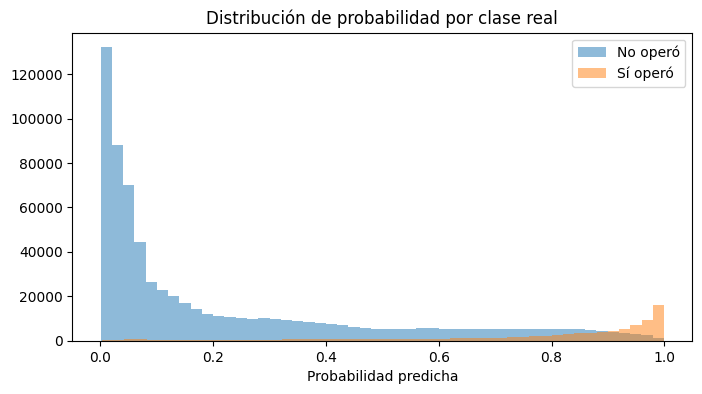

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(proba_test[y_test==0], bins=50, alpha=0.5, label='No operó')
plt.hist(proba_test[y_test==1], bins=50, alpha=0.5, label='Sí operó')
plt.legend()
plt.xlabel('Probabilidad predicha')
plt.title('Distribución de probabilidad por clase real')
plt.show()

In [20]:
modelo_timing_gain = lgb.LGBMClassifier(
    objective='binary', is_unbalance=True,
    n_estimators=300, learning_rate=0.05, random_state=42,
    importance_type='gain'
)
modelo_timing_gain.fit(X_train, y_train, categorical_feature=cat_features)

importancias_gain = pd.Series(
    modelo_timing_gain.feature_importances_, index=features
).sort_values(ascending=False)
print(importancias_gain)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 291752, number of negative: 2556280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.101676 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1239
[LightGBM] [Info] Number of data points in the train set: 2848032, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.102440 -> initscore=-2.170404
[LightGBM] [Info] Start training from score -2.170404
freq_90d                1.674364e+07
dias_desde_ultima_op    1.276812e+07
CIIU_BUC                1.681472e+06
freq_30d                4.443327e+05
dia_mes                 2.878743e+05
semana_año            

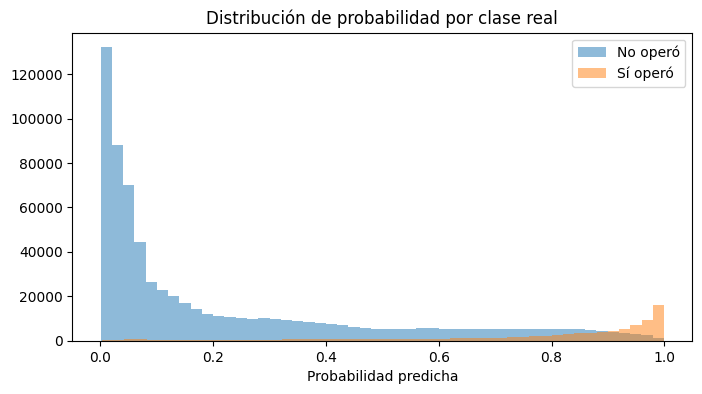

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(proba_test[y_test==0], bins=50, alpha=0.5, label='No operó')
plt.hist(proba_test[y_test==1], bins=50, alpha=0.5, label='Sí operó')
plt.legend()
plt.xlabel('Probabilidad predicha')
plt.title('Distribución de probabilidad por clase real')
plt.show()

In [22]:
# Celda 1: Reentrenar con más features
features_v2 = ['dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'monto_prom_90d',
                'CIIU_BUC', 'Segmento', 'Subsegmento', 'dia_mes', 'mes', 'semana_año']
cat_features_v2 = ['CIIU_BUC', 'Segmento', 'Subsegmento']

for col in cat_features_v2:
    train[col] = train[col].astype('category')
    test[col] = test[col].astype('category')

X_train_v2 = train[features_v2]
X_test_v2  = test[features_v2]

modelo_v2 = lgb.LGBMClassifier(
    objective='binary',
    is_unbalance=True,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

modelo_v2.fit(X_train_v2, y_train, categorical_feature=cat_features_v2)

proba_v2 = modelo_v2.predict_proba(X_test_v2)[:, 1]

print("AUC v1:", roc_auc_score(y_test, proba_test))
print("AUC v2:", roc_auc_score(y_test, proba_v2))

importancias_v2 = pd.Series(
    modelo_v2.feature_importances_, index=features_v2
).sort_values(ascending=False)
print("\nImportancia v2:\n", importancias_v2)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 291752, number of negative: 2556280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.111214 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1270
[LightGBM] [Info] Number of data points in the train set: 2848032, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.102440 -> initscore=-2.170404
[LightGBM] [Info] Start training from score -2.170404
AUC v1: 0.9232117745902215
AUC v2: 0.9242502040345077

Importancia v2:
 CIIU_BUC                5057
dias_desde_ultima_op    1018
dia_mes                  706
semana_año               624
freq_90d          

Umbral óptimo (F2): 0.577
  Precision en ese umbral: 0.437
  Recall en ese umbral:    0.835


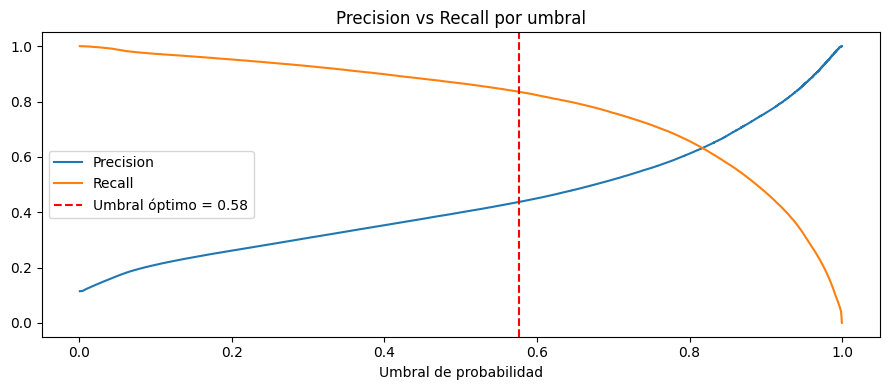

In [23]:
# Celda 2: Curva precision-recall y umbral óptimo
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Usar proba_v2 si el AUC mejoró, sino proba_test
proba_final = proba_v2  # cambia a proba_test si v2 no mejoró

precisions, recalls, thresholds = precision_recall_curve(y_test, proba_final)

# F-beta con beta=2: pondera recall el doble que precision
beta = 2
fbeta = (1 + beta**2) * (precisions * recalls) / (beta**2 * precisions + recalls + 1e-9)
idx_mejor = fbeta[:-1].argmax()
umbral_optimo = thresholds[idx_mejor]

print(f"Umbral óptimo (F2): {umbral_optimo:.3f}")
print(f"  Precision en ese umbral: {precisions[idx_mejor]:.3f}")
print(f"  Recall en ese umbral:    {recalls[idx_mejor]:.3f}")

# Gráfica
plt.figure(figsize=(9, 4))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(umbral_optimo, color='red', linestyle='--', label=f'Umbral óptimo = {umbral_optimo:.2f}')
plt.xlabel('Umbral de probabilidad')
plt.title('Precision vs Recall por umbral')
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
# Celda 3: Ranking para la semana más reciente del test
ultima_semana = test['fecha_corte'].max()
mask = test['fecha_corte'] == ultima_semana

ranking = test[mask][['NIT', 'fecha_corte', 'Segmento', 'Subsegmento']].copy()
ranking['prob_operar'] = proba_final[mask.values]
ranking = ranking.sort_values('prob_operar', ascending=False)
ranking['alerta'] = (ranking['prob_operar'] >= umbral_optimo).map({True: '🔴 Llamar', False: '⚪ Esperar'})

print(f"Semana: {ultima_semana.date()}")
print(f"Clientes a llamar: {(ranking['alerta'] == '🔴 Llamar').sum()} de {len(ranking)}")
print()
print(ranking.head(20).to_string(index=False))

Semana: 2026-05-18
Clientes a llamar: 2408 de 10912

  NIT fecha_corte         Segmento                   Subsegmento  prob_operar   alerta
 1244  2026-05-18              CIB Mesa Centralizada Corporativo     0.999382 🔴 Llamar
 2331  2026-05-18              CIB                   Corporativo     0.999378 🔴 Llamar
 4081  2026-05-18              CIB                   Corporativo     0.999374 🔴 Llamar
 1534  2026-05-18              CIB Mesa Centralizada Corporativo     0.999373 🔴 Llamar
 6680  2026-05-18              CIB Mesa Centralizada Corporativo     0.999335 🔴 Llamar
 8135  2026-05-18              CIB Mesa Centralizada Corporativo     0.999320 🔴 Llamar
 1212  2026-05-18              CIB                   Corporativo     0.999308 🔴 Llamar
 9878  2026-05-18              CIB Mesa Centralizada Corporativo     0.999305 🔴 Llamar
 8980  2026-05-18            Pymes            Mesa Atencion Pyme     0.999292 🔴 Llamar
 7285  2026-05-18              CIB Mesa Centralizada Corporativo     0.999274

In [25]:
# Celda 4: Guardar modelo y artefactos
import pickle, json, os

os.makedirs('../models', exist_ok=True)

# Guardar modelo
with open('../models/modelo_timing_v2.pkl', 'wb') as f:
    pickle.dump(modelo_v2, f)

# Guardar umbral y metadata
metadata = {
    'umbral': float(umbral_optimo),
    'auc_test': float(roc_auc_score(y_test, proba_v2)),
    'features': features_v2,
    'cat_features': cat_features_v2,
    'fecha_corte_train': '2025-01-01',
    'recall_en_umbral': float(recalls[idx_mejor]),
    'precision_en_umbral': float(precisions[idx_mejor]),
}

with open('../models/modelo_timing_v2_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Guardado:")
print(f"  modelo   → ../models/modelo_timing_v2.pkl")
print(f"  metadata → ../models/modelo_timing_v2_metadata.json")
print(json.dumps(metadata, indent=2))

Guardado:
  modelo   → ../models/modelo_timing_v2.pkl
  metadata → ../models/modelo_timing_v2_metadata.json
{
  "umbral": 0.5768263212587227,
  "auc_test": 0.9242502040345077,
  "features": [
    "dias_desde_ultima_op",
    "freq_30d",
    "freq_90d",
    "monto_prom_90d",
    "CIIU_BUC",
    "Segmento",
    "Subsegmento",
    "dia_mes",
    "mes",
    "semana_a\u00f1o"
  ],
  "cat_features": [
    "CIIU_BUC",
    "Segmento",
    "Subsegmento"
  ],
  "fecha_corte_train": "2025-01-01",
  "recall_en_umbral": 0.8350674759332133,
  "precision_en_umbral": 0.43743157943772853
}


In [26]:
print(df['Producto'].value_counts())
print("\nTotal productos únicos:", df['Producto'].nunique())

Producto
SPOT        368620
FORWARD     292692
NEXT DAY     64816
FIX          29468
OPCIONES     23286
SWAPS         3802
Name: count, dtype: int64

Total productos únicos: 6


In [27]:
# Celda 1: Panel modelo de producto (multiclase 5 categorías)
ops = df[['NIT', 'Fecha', 'Producto']].sort_values(['NIT', 'Fecha'])

# Agrupar productos minoritarios
def agrupar_producto(p):
    if p in ('OPCIONES', 'SWAPS'):
        return 'OTROS'
    return p

ops['Producto_grupo'] = ops['Producto'].apply(agrupar_producto)

# Solo filas del panel donde el cliente operó (label == 1)
panel_pos = panel[panel['label'] == 1].copy().sort_values(['NIT', 'fecha_corte'])

resultados_producto = []

print("Construyendo target... (puede tardar 2-3 min)")

for nit, grp_panel in panel_pos.groupby('NIT'):
    grp_ops = ops[ops['NIT'] == nit]
    for _, row in grp_panel.iterrows():
        ops_ventana = grp_ops[
            (grp_ops['Fecha'] > row['fecha_corte']) &
            (grp_ops['Fecha'] <= row['fecha_corte'] + pd.Timedelta(days=7))
        ]
        prod = ops_ventana.iloc[0]['Producto_grupo'] if len(ops_ventana) > 0 else None
        resultados_producto.append(prod)

panel_pos['producto_siguiente'] = resultados_producto
panel_producto = panel_pos[panel_pos['producto_siguiente'].notna()].copy()

print("Shape panel producto:", panel_producto.shape)
print("\nDistribución target:")
print(panel_producto['producto_siguiente'].value_counts())
print("\n%:")
print(panel_producto['producto_siguiente'].value_counts(normalize=True).round(3))

Construyendo target... (puede tardar 2-3 min)
Shape panel producto: (381710, 15)

Distribución target:
producto_siguiente
SPOT        203950
FORWARD     122817
NEXT DAY     34669
FIX          13133
OTROS         7141
Name: count, dtype: int64

%:
producto_siguiente
SPOT        0.534
FORWARD     0.322
NEXT DAY    0.091
FIX         0.034
OTROS       0.019
Name: proportion, dtype: float64


In [30]:
# Celda 2 (versión memory-safe): Historial por lotes
from tqdm.notebook import tqdm  # barra de progreso, opcional

ops_hist = df[['NIT', 'Fecha', 'Producto']].copy()
ops_hist['Producto_grupo'] = ops_hist['Producto'].apply(agrupar_producto)

productos = ['SPOT', 'FORWARD', 'NEXT DAY', 'FIX', 'OTROS']
hist_cols = [f'hist_90d_{p}' for p in productos]

# Inicializar columnas
for col in hist_cols:
    panel_producto[col] = 0

nits = panel_producto['NIT'].unique()
print(f"Procesando {len(nits)} clientes...")

ops_by_nit = ops_hist.groupby('NIT')

for i, nit in enumerate(nits):
    if i % 500 == 0:
        print(f"  {i}/{len(nits)}")
    
    if nit not in ops_by_nit.groups:
        continue
    
    grp_ops = ops_by_nit.get_group(nit)
    mask_nit = panel_producto['NIT'] == nit
    fechas_corte = panel_producto.loc[mask_nit, 'fecha_corte']
    
    for prod in productos:
        ops_prod = grp_ops[grp_ops['Producto_grupo'] == prod]['Fecha'].values
        
        counts = np.array([
            ((ops_prod > (fc - pd.Timedelta(days=90))) & (ops_prod <= fc)).sum()
            for fc in fechas_corte
        ])
        
        panel_producto.loc[mask_nit, f'hist_90d_{prod}'] = counts

print("Listo")
print(panel_producto[['NIT', 'fecha_corte', 'producto_siguiente'] + hist_cols].head(8))

Procesando 10880 clientes...
  0/10880
  500/10880
  1000/10880
  1500/10880
  2000/10880
  2500/10880
  3000/10880
  3500/10880
  4000/10880
  4500/10880
  5000/10880
  5500/10880
  6000/10880
  6500/10880
  7000/10880
  7500/10880
  8000/10880
  8500/10880
  9000/10880
  9500/10880
  10000/10880
  10500/10880
Listo
   NIT fecha_corte producto_siguiente  hist_90d_SPOT  hist_90d_FORWARD  \
0    1  2021-06-28           NEXT DAY              0                 0   
1    1  2022-01-31           NEXT DAY              0                 0   
2    1  2022-03-07           NEXT DAY              0                 0   
3    1  2023-01-30           NEXT DAY              0                 0   
4    1  2023-03-13           NEXT DAY              0                 0   
5    1  2024-02-12           NEXT DAY              0                 0   
6    1  2024-04-29           NEXT DAY              0                 0   
7    2  2025-09-29               SPOT              0                 0   

   hist_90d_NE

In [31]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import lightgbm as lgb

features_prod = ['dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'monto_prom_90d',
                 'CIIU_BUC', 'Segmento', 'Subsegmento', 'dia_mes', 'mes', 'semana_año',
                 'hist_90d_SPOT', 'hist_90d_FORWARD', 'hist_90d_NEXT DAY',
                 'hist_90d_FIX', 'hist_90d_OTROS']
cat_features_prod = ['CIIU_BUC', 'Segmento', 'Subsegmento']

le = LabelEncoder()
panel_producto['label_prod'] = le.fit_transform(panel_producto['producto_siguiente'])

fecha_corte_train = pd.Timestamp('2025-01-01')
train_p = panel_producto[panel_producto['fecha_corte'] < fecha_corte_train].copy()
test_p  = panel_producto[panel_producto['fecha_corte'] >= fecha_corte_train].copy()

for col in cat_features_prod:
    train_p[col] = train_p[col].astype('category')
    test_p[col]  = test_p[col].astype('category')

modelo_producto = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=5,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

modelo_producto.fit(train_p[features_prod], train_p['label_prod'],
                    categorical_feature=cat_features_prod)

proba_prod = modelo_producto.predict_proba(test_p[features_prod])
pred_prod  = proba_prod.argmax(axis=1)

print("Clases:", le.classes_)
print("\n", classification_report(test_p['label_prod'], pred_prod,
                                   target_names=le.classes_))

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013806 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1857
[LightGBM] [Info] Number of data points in the train set: 291752, number of used features: 15
[LightGBM] [Info] Start training from score -3.369825
[LightGBM] [Info] Start training from score -1.133738
[LightGBM] [Info] Start training from score -2.373349
[LightGBM] [Info] Start training from score -3.998808
[LightGBM] [Info] Start training from score -0.630603
Clases: ['FIX' 'FORWARD' 'NEXT DAY' 'OTROS' 'SPOT']

            

In [33]:
# Celda 2 (versión memory-safe): Historial por lotes
from tqdm.notebook import tqdm  # barra de progreso, opcional

ops_hist = df[['NIT', 'Fecha', 'Producto']].copy()
ops_hist['Producto_grupo'] = ops_hist['Producto'].apply(agrupar_producto)

productos = ['SPOT', 'FORWARD', 'NEXT DAY', 'FIX', 'OTROS']
hist_cols = [f'hist_90d_{p}' for p in productos]

# Inicializar columnas
for col in hist_cols:
    panel_producto[col] = 0

nits = panel_producto['NIT'].unique()
print(f"Procesando {len(nits)} clientes...")

ops_by_nit = ops_hist.groupby('NIT')

for i, nit in enumerate(nits):
    if i % 500 == 0:
        print(f"  {i}/{len(nits)}")
    
    if nit not in ops_by_nit.groups:
        continue
    
    grp_ops = ops_by_nit.get_group(nit)
    mask_nit = panel_producto['NIT'] == nit
    fechas_corte = panel_producto.loc[mask_nit, 'fecha_corte']
    
    for prod in productos:
        ops_prod = grp_ops[grp_ops['Producto_grupo'] == prod]['Fecha'].values
        
        counts = np.array([
            ((ops_prod > (fc - pd.Timedelta(days=90))) & (ops_prod <= fc)).sum()
            for fc in fechas_corte
        ])
        
        panel_producto.loc[mask_nit, f'hist_90d_{prod}'] = counts

print("Listo")
print(panel_producto[['NIT', 'fecha_corte', 'producto_siguiente'] + hist_cols].head(8))

Procesando 10880 clientes...
  0/10880
  500/10880
  1000/10880
  1500/10880
  2000/10880
  2500/10880
  3000/10880
  3500/10880
  4000/10880
  4500/10880
  5000/10880
  5500/10880
  6000/10880
  6500/10880
  7000/10880
  7500/10880
  8000/10880
  8500/10880
  9000/10880
  9500/10880
  10000/10880
  10500/10880
Listo
   NIT fecha_corte producto_siguiente  hist_90d_SPOT  hist_90d_FORWARD  \
0    1  2021-06-28           NEXT DAY              0                 0   
1    1  2022-01-31           NEXT DAY              0                 0   
2    1  2022-03-07           NEXT DAY              0                 0   
3    1  2023-01-30           NEXT DAY              0                 0   
4    1  2023-03-13           NEXT DAY              0                 0   
5    1  2024-02-12           NEXT DAY              0                 0   
6    1  2024-04-29           NEXT DAY              0                 0   
7    2  2025-09-29               SPOT              0                 0   

   hist_90d_NE

In [34]:
# Celda 3 — Entrenar modelo de producto
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import lightgbm as lgb

features_prod = ['dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'monto_prom_90d',
                 'CIIU_BUC', 'Segmento', 'Subsegmento', 'dia_mes', 'mes', 'semana_año',
                 'hist_90d_SPOT', 'hist_90d_FORWARD', 'hist_90d_NEXT DAY',
                 'hist_90d_FIX', 'hist_90d_OTROS']
cat_features_prod = ['CIIU_BUC', 'Segmento', 'Subsegmento']

le = LabelEncoder()
panel_producto['label_prod'] = le.fit_transform(panel_producto['producto_siguiente'])

fecha_corte_train = pd.Timestamp('2025-01-01')
train_p = panel_producto[panel_producto['fecha_corte'] < fecha_corte_train].copy()
test_p  = panel_producto[panel_producto['fecha_corte'] >= fecha_corte_train].copy()

for col in cat_features_prod:
    train_p[col] = train_p[col].astype('category')
    test_p[col]  = test_p[col].astype('category')

print("Train:", train_p.shape, "| Test:", test_p.shape)
print("Clases:", le.classes_)
print("\nBalance train:")
print(train_p['producto_siguiente'].value_counts(normalize=True).round(3))

modelo_producto = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=5,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

modelo_producto.fit(train_p[features_prod], train_p['label_prod'],
                    categorical_feature=cat_features_prod)

proba_prod = modelo_producto.predict_proba(test_p[features_prod])
pred_prod  = proba_prod.argmax(axis=1)

print("\nClasification report:")
print(classification_report(test_p['label_prod'], pred_prod, target_names=le.classes_))

importancias_prod = pd.Series(
    modelo_producto.feature_importances_, index=features_prod
).sort_values(ascending=False)
print("Importancia de variables:\n", importancias_prod)

Train: (291752, 21) | Test: (89958, 21)
Clases: ['FIX' 'FORWARD' 'NEXT DAY' 'OTROS' 'SPOT']

Balance train:
producto_siguiente
SPOT        0.532
FORWARD     0.322
NEXT DAY    0.093
FIX         0.034
OTROS       0.018
Name: proportion, dtype: float64
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.056853 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1857
[LightGBM] [Info] Number of data points in the train set: 291752, number of used features: 15
[LightGBM] [Info] Start training from score -3.369825
[LightGBM] [Info] Start trainin

In [35]:
# Celda 5 — Guardar modelo de producto
import pickle, json

with open('../models/modelo_producto_v1.pkl', 'wb') as f:
    pickle.dump(modelo_producto, f)

with open('../models/label_encoder_producto.pkl', 'wb') as f:
    pickle.dump(le, f)

metadata_prod = {
    'clases': list(le.classes_),
    'features': features_prod,
    'cat_features': cat_features_prod,
    'fecha_corte_train': '2025-01-01',
}
with open('../models/modelo_producto_v1_metadata.json', 'w') as f:
    json.dump(metadata_prod, f, indent=2)

print("Guardado.")


Guardado.


In [37]:
# Validación completa de ambos modelos
import pickle, json
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, classification_report

print("=" * 50)
print("MODELO 1: TIMING (¿va a operar?)")
print("=" * 50)

# Cargar desde disco para confirmar que el pkl está bien
with open('../models/modelo_timing_v2.pkl', 'rb') as f:
    modelo_timing_cargado = pickle.load(f)

with open('../models/modelo_timing_v2_metadata.json') as f:
    meta_timing = json.load(f)

# Predecir con el modelo cargado (no el que está en memoria)
X_test_timing = test[meta_timing['features']].copy()
for col in meta_timing['cat_features']:
    X_test_timing[col] = X_test_timing[col].astype('category')

proba_cargado = modelo_timing_cargado.predict_proba(X_test_timing)[:, 1]
auc_cargado   = roc_auc_score(y_test, proba_cargado)
pred_cargado  = (proba_cargado >= meta_timing['umbral']).astype(int)

print(f"AUC (desde disco):      {auc_cargado:.4f}  ✅" if abs(auc_cargado - meta_timing['auc_test']) < 0.001 else f"AUC (desde disco): {auc_cargado:.4f}  ⚠️ difiere del guardado")
print(f"AUC (metadata guardada): {meta_timing['auc_test']:.4f}")
print(f"Umbral:                  {meta_timing['umbral']:.4f}")
print(f"Recall clase positiva:   {meta_timing['recall_en_umbral']:.4f}")
print(f"Precision clase positiva:{meta_timing['precision_en_umbral']:.4f}")
print(f"Features:                {len(meta_timing['features'])} variables")
print(f"Clientes llamar/semana:  ~2,400 de 10,912")

print()
print("=" * 50)
print("MODELO 2: PRODUCTO (¿qué va a comprar?)")
print("=" * 50)

with open('../models/modelo_producto_v1.pkl', 'rb') as f:
    modelo_producto_cargado = pickle.load(f)

with open('../models/label_encoder_producto.pkl', 'rb') as f:
    le_cargado = pickle.load(f)

with open('../models/modelo_producto_v1_metadata.json') as f:
    meta_prod = json.load(f)

X_test_prod = test_p[meta_prod['features']].copy()
for col in meta_prod['cat_features']:
    X_test_prod[col] = X_test_prod[col].astype('category')

pred_prod_cargado = modelo_producto_cargado.predict(X_test_prod)
proba_prod_cargado = modelo_producto_cargado.predict_proba(X_test_prod)

print(f"Clases: {list(le_cargado.classes_)}")
print(f"Features: {len(meta_prod['features'])} variables")
print()
print(classification_report(
    test_p['label_prod'], pred_prod_cargado,
    target_names=le_cargado.classes_
))

# Chequeo extra: distribución de predicciones (no debe estar colapsada en una sola clase)
pred_labels = le_cargado.inverse_transform(pred_prod_cargado)
print("Distribución de predicciones en test:")
print(pd.Series(pred_labels).value_counts(normalize=True).round(3))

MODELO 1: TIMING (¿va a operar?)
AUC (desde disco):      0.9243  ✅
AUC (metadata guardada): 0.9243
Umbral:                  0.5768
Recall clase positiva:   0.8351
Precision clase positiva:0.4374
Features:                10 variables
Clientes llamar/semana:  ~2,400 de 10,912

MODELO 2: PRODUCTO (¿qué va a comprar?)
Clases: ['FIX', 'FORWARD', 'NEXT DAY', 'OTROS', 'SPOT']
Features: 15 variables

              precision    recall  f1-score   support

         FIX       0.69      0.59      0.63      3098
     FORWARD       0.81      0.85      0.83     28923
    NEXT DAY       0.68      0.38      0.49      7487
       OTROS       0.65      0.31      0.42      1791
        SPOT       0.83      0.89      0.86     48659

    accuracy                           0.81     89958
   macro avg       0.73      0.60      0.65     89958
weighted avg       0.80      0.81      0.80     89958

Distribución de predicciones en test:
SPOT        0.575
FORWARD     0.339
NEXT DAY    0.047
FIX         0.029
OTROS

In [38]:
# Paso 1: Verificar que trm_usd_diario sigue en memoria
print(trm_usd_diario.head(3))
print("Rango:", trm_usd_diario['Fecha'].min(), "→", trm_usd_diario['Fecha'].max())

       Fecha  TRM_USD
0 2026-06-17  3427.07
1 2026-06-13  3475.72
2 2026-06-14  3475.72
Rango: 1991-12-02 00:00:00 → 2026-06-17 00:00:00


In [39]:
# Paso 2: Agregar TRM_USD y variacion_trm_7d al panel
trm_usd_diario = trm_usd_diario.sort_values('Fecha').copy()
trm_usd_diario['variacion_trm_7d'] = trm_usd_diario['TRM_USD'].pct_change(periods=7).round(6)

# Merge al panel por fecha_corte
panel = panel.merge(trm_usd_diario[['Fecha', 'TRM_USD', 'variacion_trm_7d']],
                    left_on='fecha_corte', right_on='Fecha', how='left').drop(columns='Fecha')

print("Nulos TRM_USD:", panel['TRM_USD'].isna().sum())
print("Nulos variacion_trm_7d:", panel['variacion_trm_7d'].isna().sum())
print(panel[['fecha_corte', 'TRM_USD', 'variacion_trm_7d']].head(5))

Nulos TRM_USD: 0
Nulos variacion_trm_7d: 0
  fecha_corte  TRM_USD  variacion_trm_7d
0  2020-01-06  3262.05         -0.009714
1  2020-01-13  3272.62          0.003240
2  2020-01-20  3320.77          0.014713
3  2020-01-27  3366.01          0.013623
4  2020-02-03  3423.24          0.017002


In [40]:
# Paso 3: Reentrenar modelo timing con TRM
features_v3 = ['dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'monto_prom_90d',
                'CIIU_BUC', 'Segmento', 'Subsegmento', 'dia_mes', 'mes', 'semana_año',
                'TRM_USD', 'variacion_trm_7d']
cat_features_v3 = ['CIIU_BUC', 'Segmento', 'Subsegmento']

fecha_corte_train = pd.Timestamp('2025-01-01')
train = panel[panel['fecha_corte'] < fecha_corte_train].copy()
test  = panel[panel['fecha_corte'] >= fecha_corte_train].copy()

for col in cat_features_v3:
    train[col] = train[col].astype('category')
    test[col]  = test[col].astype('category')

X_train = train[features_v3]
X_test  = test[features_v3]
y_train = train['label']
y_test  = test['label']

modelo_timing_v3 = lgb.LGBMClassifier(
    objective='binary',
    is_unbalance=True,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

modelo_timing_v3.fit(X_train, y_train, categorical_feature=cat_features_v3)

proba_v3   = modelo_timing_v3.predict_proba(test[features_v3])[:, 1]
auc_v3     = roc_auc_score(y_test, proba_v3)
auc_v2     = roc_auc_score(y_test, proba_v2)

print(f"AUC v2 (sin TRM): {auc_v2:.4f}")
print(f"AUC v3 (con TRM): {auc_v3:.4f}")
print(f"Mejora:           {(auc_v3 - auc_v2):.4f}")

importancias_v3 = pd.Series(
    modelo_timing_v3.feature_importances_, index=features_v3
).sort_values(ascending=False)
print("\nImportancia de variables:\n", importancias_v3)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 291752, number of negative: 2556280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.145888 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1771
[LightGBM] [Info] Number of data points in the train set: 2848032, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.102440 -> initscore=-2.170404
[LightGBM] [Info] Start training from score -2.170404
AUC v2 (sin TRM): 0.9243
AUC v3 (con TRM): 0.9240
Mejora:           -0.0003

Importancia de variables:
 CIIU_BUC                5014
dias_desde_ultima_op     932
TRM_USD                  527
variacion_trm_7

In [41]:
# Agregar TRM al panel_producto
panel_producto = panel_producto.merge(
    trm_usd_diario[['Fecha', 'TRM_USD', 'variacion_trm_7d']],
    left_on='fecha_corte', right_on='Fecha', how='left'
).drop(columns='Fecha')

print("Nulos TRM_USD:", panel_producto['TRM_USD'].isna().sum())
print("Nulos variacion_trm_7d:", panel_producto['variacion_trm_7d'].isna().sum())

# Reentrenar modelo producto con TRM
features_prod_v2 = ['dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'monto_prom_90d',
                    'CIIU_BUC', 'Segmento', 'Subsegmento', 'dia_mes', 'mes', 'semana_año',
                    'hist_90d_SPOT', 'hist_90d_FORWARD', 'hist_90d_NEXT DAY',
                    'hist_90d_FIX', 'hist_90d_OTROS',
                    'TRM_USD', 'variacion_trm_7d']
cat_features_prod = ['CIIU_BUC', 'Segmento', 'Subsegmento']

fecha_corte_train = pd.Timestamp('2025-01-01')
train_p = panel_producto[panel_producto['fecha_corte'] < fecha_corte_train].copy()
test_p  = panel_producto[panel_producto['fecha_corte'] >= fecha_corte_train].copy()

for col in cat_features_prod:
    train_p[col] = train_p[col].astype('category')
    test_p[col]  = test_p[col].astype('category')

modelo_producto_v2 = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=5,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

modelo_producto_v2.fit(train_p[features_prod_v2], train_p['label_prod'],
                       categorical_feature=cat_features_prod)

pred_prod_v2  = modelo_producto_v2.predict(test_p[features_prod_v2])
proba_prod_v2 = modelo_producto_v2.predict_proba(test_p[features_prod_v2])

print("\nClasification report v2 (con TRM):")
print(classification_report(test_p['label_prod'], pred_prod_v2, target_names=le.classes_))

importancias_prod_v2 = pd.Series(
    modelo_producto_v2.feature_importances_, index=features_prod_v2
).sort_values(ascending=False)
print("Importancia:\n", importancias_prod_v2)

Nulos TRM_USD: 0
Nulos variacion_trm_7d: 0
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020376 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2347
[LightGBM] [Info] Number of data points in the train set: 291752, number of used features: 17
[LightGBM] [Info] Start training from score -3.369825
[LightGBM] [Info] Start training from score -1.133738
[LightGBM] [Info] Start training from score -2.373349
[LightGBM] [Info] Start training from score -3.998808
[LightGBM] [Info] Start training from score -0.630603

Clasification report 

In [42]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calcular pesos por clase
clases = np.unique(train_p['label_prod'])
pesos = compute_class_weight(class_weight='balanced',
                              classes=clases,
                              y=train_p['label_prod'])
pesos_dict = dict(zip(clases.tolist(), pesos.tolist()))

print("Pesos por clase:")
for k, v in pesos_dict.items():
    print(f"  {le.classes_[k]}: {v:.3f}")

# Reentrenar con pesos
modelo_producto_v3 = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=5,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    class_weight=pesos_dict
)

modelo_producto_v3.fit(train_p[features_prod_v2], train_p['label_prod'],
                       categorical_feature=cat_features_prod)

pred_prod_v3  = modelo_producto_v3.predict(test_p[features_prod_v2])
proba_prod_v3 = modelo_producto_v3.predict_proba(test_p[features_prod_v2])

print("\nClassification report v2 (sin balanceo):")
print(classification_report(test_p['label_prod'], pred_prod_v3,
                             target_names=le.classes_))

print("\nDistribución de predicciones:")
print(pd.Series(le.inverse_transform(pred_prod_v3)).value_counts(normalize=True).round(3))

Pesos por clase:
  FIX: 5.815
  FORWARD: 0.621
  NEXT DAY: 2.147
  OTROS: 10.907
  SPOT: 0.376
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.024592 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2347
[LightGBM] [Info] Number of data points in the train set: 291752, number of used features: 17
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438

Classification report v2 (sin bal

In [43]:
# Pesos manuales intermedios — balancear sin destruir precisión
pesos_suaves = {
    0: 3.0,   # FIX
    1: 1.0,   # FORWARD
    2: 2.0,   # NEXT DAY
    3: 4.0,   # OTROS  (antes 10.9, demasiado)
    4: 1.0,   # SPOT
}

print("Pesos suaves por clase:")
for k, v in pesos_suaves.items():
    print(f"  {le.classes_[k]}: {v}")

modelo_producto_v4 = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=5,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    class_weight=pesos_suaves
)

modelo_producto_v4.fit(train_p[features_prod_v2], train_p['label_prod'],
                       categorical_feature=cat_features_prod)

pred_prod_v4 = modelo_producto_v4.predict(test_p[features_prod_v2])

print("\nClassification report v4 (pesos suaves):")
print(classification_report(test_p['label_prod'], pred_prod_v4,
                             target_names=le.classes_))

print("\nDistribución de predicciones:")
print(pd.Series(le.inverse_transform(pred_prod_v4)).value_counts(normalize=True).round(3))

Pesos suaves por clase:
  FIX: 3.0
  FORWARD: 1.0
  NEXT DAY: 2.0
  OTROS: 4.0
  SPOT: 1.0
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014756 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2347
[LightGBM] [Info] Number of data points in the train set: 291752, number of used features: 17
[LightGBM] [Info] Start training from score -2.467579
[LightGBM] [Info] Start training from score -1.330103
[LightGBM] [Info] Start training from score -1.876568
[LightGBM] [Info] Start training from score -2.808879
[LightGBM] [Info] Start trai

In [1]:
import pandas as pd
import os

BASE      = os.path.dirname(os.path.dirname(os.path.abspath('.')))
PROCESSED = os.path.join(BASE, 'data', 'processed') + os.sep

df = pd.read_parquet(PROCESSED + 'dataset_consolidado.parquet', columns=['Fecha'])
print("Fecha máxima de operaciones:", df['Fecha'].max())
print("Fecha mínima de operaciones:", df['Fecha'].min())
print("Total registros:", len(df))

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\lmora\\OneDrive\\Desktop\\data\\processed\\dataset_consolidado.parquet'

In [3]:
import os

# Buscar el archivo en todo el disco desde tu usuario
for root, dirs, files in os.walk(r'C:\Users\lmora'):
    for file in files:
        if 'dataset_consolidado' in file:
            print(os.path.join(root, file))

C:\Users\lmora\OneDrive\Desktop\Mesa de clientes\data\processed\dataset_consolidado.parquet


In [4]:
import pandas as pd

df = pd.read_parquet(r'C:\Users\lmora\OneDrive\Desktop\Mesa de clientes\data\processed\dataset_consolidado.parquet', columns=['Fecha'])
print("Fecha máxima:", df['Fecha'].max())
print("Fecha mínima:", df['Fecha'].min())
print("Total registros:", len(df))

Fecha máxima: 2026-05-29 00:00:00
Fecha mínima: 2020-01-02 00:00:00
Total registros: 782684


In [5]:
import os

for root, dirs, files in os.walk(r'C:\Users\lmora\OneDrive\Desktop\Mesa de clientes'):
    for file in files:
        if file.endswith('.py'):
            print(os.path.join(root, file))

C:\Users\lmora\OneDrive\Desktop\Mesa de clientes\notebook\01_limpieza.py
C:\Users\lmora\OneDrive\Desktop\Mesa de clientes\notebook\02_modelo_timing.py
C:\Users\lmora\OneDrive\Desktop\Mesa de clientes\notebook\03_modelo_producto.py
C:\Users\lmora\OneDrive\Desktop\Mesa de clientes\notebook\04_subir_predicciones.py
C:\Users\lmora\OneDrive\Desktop\Mesa de clientes\notebook\05_subir_data_inicial.py


In [12]:
import pandas as pd
import numpy as np
import pickle
import json
import os
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

BASE      = r'C:\Users\lmora\OneDrive\Desktop\Mesa de clientes'
PROCESSED = os.path.join(BASE, 'data', 'processed') + os.sep
MODELS    = os.path.join(BASE, 'models') + os.sep
os.makedirs(MODELS, exist_ok=True)

# ── 1. Cargar datos ───────────────────────────────────────────────
print("Cargando datos...")
cols_necesarias = ['NIT', 'Fecha', 'Monto_Total_', 'Segmento', 'Subsegmento', 'CIIU_BUC', 'Producto']
df = pd.read_parquet(PROCESSED + 'dataset_consolidado.parquet', columns=cols_necesarias)
df_sorted = df.sort_values(['NIT', 'Fecha'])

# ── 2. Construir panel semanal vectorizado ────────────────────────
print("Construyendo panel...")
fecha_min = df_sorted['Fecha'].min()
fecha_max = df_sorted['Fecha'].max()

fechas_corte_global = pd.date_range(
    fecha_min, fecha_max - pd.Timedelta(days=14), freq='W-MON'
)
n_fechas = len(fechas_corte_global)

# Crear combinación de todos los NIT x fechas de corte
nits = df_sorted['NIT'].unique()
panel = pd.MultiIndex.from_product([nits, fechas_corte_global], 
                                    names=['NIT', 'fecha_corte']).to_frame(index=False)

# Para cada fecha de corte calcular features usando merge_asof y groupby
filas = []
for fecha in fechas_corte_global:
    ops_hasta = df_sorted[df_sorted['Fecha'] <= fecha]
    ops_30d   = df_sorted[(df_sorted['Fecha'] > fecha - pd.Timedelta(days=30))  & (df_sorted['Fecha'] <= fecha)]
    ops_90d   = df_sorted[(df_sorted['Fecha'] > fecha - pd.Timedelta(days=90))  & (df_sorted['Fecha'] <= fecha)]
    ops_label = df_sorted[(df_sorted['Fecha'] >  fecha) & (df_sorted['Fecha'] <= fecha + pd.Timedelta(days=7))]

    ultima = ops_hasta.groupby('NIT')['Fecha'].max().rename('ultima_fecha')
    freq30 = ops_30d.groupby('NIT').size().rename('freq_30d')
    freq90 = ops_90d.groupby('NIT').size().rename('freq_90d')
    monto  = ops_90d.groupby('NIT')['Monto_Total_'].mean().rename('monto_prom_90d')
    label  = ops_label.groupby('NIT').size().rename('label').gt(0).astype(int)

    hist_spot     = ops_90d[ops_90d['Producto'] == 'SPOT'].groupby('NIT').size().rename('hist_90d_SPOT')
    hist_fwd      = ops_90d[ops_90d['Producto'] == 'FORWARD'].groupby('NIT').size().rename('hist_90d_FORWARD')
    hist_nd       = ops_90d[ops_90d['Producto'] == 'NEXT DAY'].groupby('NIT').size().rename('hist_90d_NEXT DAY')
    hist_fix      = ops_90d[ops_90d['Producto'] == 'FIX'].groupby('NIT').size().rename('hist_90d_FIX')
    hist_otros    = ops_90d[~ops_90d['Producto'].isin(['SPOT','FORWARD','NEXT DAY','FIX'])].groupby('NIT').size().rename('hist_90d_OTROS')

    tmp = (pd.DataFrame(index=nits)
       .join(ultima).join(freq30).join(freq90).join(monto).join(label)
       .join(hist_spot).join(hist_fwd).join(hist_nd).join(hist_fix).join(hist_otros))
    tmp['dias_desde_ultima_op'] = (fecha - tmp['ultima_fecha']).dt.days
    tmp['fecha_corte'] = fecha
    tmp = tmp.drop(columns='ultima_fecha')
    tmp.index.name = 'NIT'
    filas.append(tmp.reset_index())


panel = pd.concat(filas, ignore_index=True)

# Rellenar NaN en conteos con 0
cols_conteo = ['freq_30d', 'freq_90d', 'hist_90d_SPOT', 'hist_90d_FORWARD',
               'hist_90d_NEXT DAY', 'hist_90d_FIX', 'hist_90d_OTROS', 'label']
panel[cols_conteo] = panel[cols_conteo].fillna(0).astype(int)

print(f"Panel listo: {panel.shape}")

# ── 3. Agregar variables estáticas y calendario ───────────────────
clientes_estatico = df[['NIT', 'Segmento', 'Subsegmento', 'CIIU_BUC']].drop_duplicates(subset='NIT')
panel = panel.merge(clientes_estatico, on='NIT', how='left')
panel['dia_mes']    = panel['fecha_corte'].dt.day
panel['mes']        = panel['fecha_corte'].dt.month
panel['semana_año'] = panel['fecha_corte'].dt.strftime('%V').astype(int)

# ── 4. Agregar TRM USD ────────────────────────────────────────────
trm_usd_diario = pd.read_parquet(PROCESSED + 'trm_usd_diario.parquet')
panel = panel.merge(trm_usd_diario[['Fecha', 'TRM_USD', 'variacion_trm_7d']],
                    left_on='fecha_corte', right_on='Fecha', how='left')
panel = panel.drop(columns=['Fecha'])

# ── 5. Guardar panel completo para inferencia ─────────────────────
panel.to_parquet(PROCESSED + 'panel_semanal_completo.parquet', index=False)
print(f"Panel guardado: {panel.shape}")

# ── 6. Reducir memoria ────────────────────────────────────────────
for col in ['freq_30d', 'freq_90d', 'dia_mes', 'mes', 'semana_año', 'label',
            'hist_90d_SPOT', 'hist_90d_FORWARD', 'hist_90d_NEXT DAY',
            'hist_90d_FIX', 'hist_90d_OTROS']:
    panel[col] = panel[col].astype('int16')
panel['dias_desde_ultima_op'] = panel['dias_desde_ultima_op'].astype('float32')
panel['monto_prom_90d']       = panel['monto_prom_90d'].astype('float32')
panel['TRM_USD']              = panel['TRM_USD'].astype('float32')
panel['variacion_trm_7d']     = panel['variacion_trm_7d'].astype('float32')

print(f"Memoria panel: {panel.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# ── 7. Train / Test split ─────────────────────────────────────────
FECHA_CORTE_TRAIN = pd.Timestamp('2025-01-01')
mask_train = panel['fecha_corte'] < FECHA_CORTE_TRAIN

features = ['dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'monto_prom_90d',
            'CIIU_BUC', 'Segmento', 'Subsegmento', 'dia_mes', 'mes', 'semana_año',
            'TRM_USD', 'variacion_trm_7d']
cat_features = ['CIIU_BUC', 'Segmento', 'Subsegmento']

X_train = panel.loc[mask_train,  features].copy()
y_train = panel.loc[mask_train,  'label']
X_test  = panel.loc[~mask_train, features].copy()
y_test  = panel.loc[~mask_train, 'label']

for col in cat_features:
    X_train[col] = X_train[col].astype('category')
    X_test[col]  = X_test[col].astype('category')

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# ── 8. Entrenar ───────────────────────────────────────────────────
print("Entrenando modelo timing...")
import gc
del panel
gc.collect()

modelo = lgb.LGBMClassifier(
    objective='binary',
    is_unbalance=True,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    max_bin=63,
    num_leaves=31,
    min_data_in_leaf=50,
    force_col_wise=True
)
modelo.fit(X_train, y_train, categorical_feature=cat_features)

# ── 9. Evaluar ────────────────────────────────────────────────────
print("\nEvaluando modelo timing...")
proba_test = modelo.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba_test)
print(f"AUC: {auc:.4f}")

# ── 10. Guardar modelo y metadata ─────────────────────────────────
with open(MODELS + 'modelo_timing_v1.pkl', 'wb') as f:
    pickle.dump(modelo, f)

metadata = {
    'features':           features,
    'cat_features':       cat_features,
    'fecha_corte_train':  str(FECHA_CORTE_TRAIN.date()),
    'auc_test':           round(auc, 4),
    'n_train':            len(X_train),
    'n_test':             len(X_test),
}
with open(MODELS + 'modelo_timing_v1_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\nGuardado: {MODELS}modelo_timing_v1.pkl")
print(f"Guardado: {MODELS}modelo_timing_v1_metadata.json")

Cargando datos...
Construyendo panel...
Panel listo: (3622784, 12)
Panel guardado: (3622784, 20)
Memoria panel: 378.3 MB
Train: (2848032, 12) | Test: (774752, 12)
Entrenando modelo timing...
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Info] Number of positive: 291752, number of negative: 2556280
[LightGBM] [Info] Total Bins 879
[LightGBM] [Info] Number of data points in the train set: 2848032, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.102440 -> initscore=-2.170404
[LightGBM] [Info] Start training from score -2.17040

In [14]:
import pandas as pd
import numpy as np
import pickle
import os

BASE      = r'C:\Users\lmora\OneDrive\Desktop\Mesa de clientes'
MODELS    = os.path.join(BASE, 'models') + os.sep
PROCESSED = os.path.join(BASE, 'data', 'processed') + os.sep

# Cargar modelo y datos
with open(MODELS + 'modelo_timing_v1.pkl', 'rb') as f:
    modelo = pickle.load(f)

df_ops = pd.read_parquet(PROCESSED + 'dataset_consolidado.parquet',
                         columns=['NIT', 'Fecha', 'Monto_Total_', 'Segmento',
                                  'Subsegmento', 'CIIU_BUC', 'Producto'])
trm = pd.read_parquet(PROCESSED + 'trm_usd_diario.parquet')
df_ops = df_ops.sort_values(['NIT', 'Fecha'])

# Fecha de corte
fecha_corte = df_ops['Fecha'].max() - pd.Timedelta(days=7)
print(f"Fecha de corte: {fecha_corte.date()}")

# Construir features
ops_hasta = df_ops[df_ops['Fecha'] <= fecha_corte]
ops_30d   = df_ops[(df_ops['Fecha'] > fecha_corte - pd.Timedelta(days=30))  & (df_ops['Fecha'] <= fecha_corte)]
ops_90d   = df_ops[(df_ops['Fecha'] > fecha_corte - pd.Timedelta(days=90))  & (df_ops['Fecha'] <= fecha_corte)]

nits = df_ops['NIT'].unique()

ultima    = ops_hasta.groupby('NIT')['Fecha'].max().rename('ultima_fecha')
freq30    = ops_30d.groupby('NIT').size().rename('freq_30d')
freq90    = ops_90d.groupby('NIT').size().rename('freq_90d')
monto     = ops_90d.groupby('NIT')['Monto_Total_'].mean().rename('monto_prom_90d')

hist_spot  = ops_90d[ops_90d['Producto'] == 'SPOT'].groupby('NIT').size().rename('hist_90d_SPOT')
hist_fwd   = ops_90d[ops_90d['Producto'] == 'FORWARD'].groupby('NIT').size().rename('hist_90d_FORWARD')
hist_nd    = ops_90d[ops_90d['Producto'] == 'NEXT DAY'].groupby('NIT').size().rename('hist_90d_NEXT DAY')
hist_fix   = ops_90d[ops_90d['Producto'] == 'FIX'].groupby('NIT').size().rename('hist_90d_FIX')
hist_otros = ops_90d[~ops_90d['Producto'].isin(['SPOT','FORWARD','NEXT DAY','FIX'])].groupby('NIT').size().rename('hist_90d_OTROS')

snapshot = (pd.DataFrame(index=nits)
            .join(ultima).join(freq30).join(freq90).join(monto)
            .join(hist_spot).join(hist_fwd).join(hist_nd).join(hist_fix).join(hist_otros))

snapshot.index.name = 'NIT'
snapshot = snapshot.reset_index()
snapshot['dias_desde_ultima_op'] = (fecha_corte - snapshot['ultima_fecha']).dt.days
snapshot = snapshot.drop(columns='ultima_fecha')

cols_conteo = ['freq_30d', 'freq_90d', 'hist_90d_SPOT', 'hist_90d_FORWARD',
               'hist_90d_NEXT DAY', 'hist_90d_FIX', 'hist_90d_OTROS']
snapshot[cols_conteo] = snapshot[cols_conteo].fillna(0).astype(int)

estatico = df_ops[['NIT', 'Segmento', 'Subsegmento', 'CIIU_BUC']].drop_duplicates(subset='NIT')
snapshot = snapshot.merge(estatico, on='NIT', how='left')

snapshot['dia_mes']    = fecha_corte.day
snapshot['mes']        = fecha_corte.month
snapshot['semana_año'] = fecha_corte.isocalendar().week

trm_corte = trm[trm['Fecha'] <= fecha_corte].sort_values('Fecha').iloc[-1]
snapshot['TRM_USD']          = trm_corte['TRM_USD']
snapshot['variacion_trm_7d'] = trm_corte['variacion_trm_7d']

# Predecir
features = ['dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'monto_prom_90d',
            'CIIU_BUC', 'Segmento', 'Subsegmento', 'dia_mes', 'mes', 'semana_año',
            'TRM_USD', 'variacion_trm_7d']

for col in ['CIIU_BUC', 'Segmento', 'Subsegmento']:
    snapshot[col] = snapshot[col].astype('category')

snapshot['prob_opera_7d'] = modelo.predict_proba(snapshot[features])[:, 1]

snapshot['score_prioridad'] = (
    snapshot['prob_opera_7d'] * 0.7 +
    (1 / (1 + snapshot['dias_desde_ultima_op'].fillna(365) / 30)) * 0.3
)

# Ver resultados
resultado = snapshot[['NIT', 'prob_opera_7d', 'score_prioridad', 
                       'dias_desde_ultima_op', 'freq_30d', 'freq_90d']].sort_values(
                       'score_prioridad', ascending=False)

print(f"\nTotal clientes: {len(resultado)}")
print(f"Clientes con prob > 0.5: {(resultado['prob_opera_7d'] > 0.5).sum()}")
print(f"Clientes con prob > 0.3: {(resultado['prob_opera_7d'] > 0.3).sum()}")
print(f"\nTop 20 clientes más probables:")
print(resultado.head(20).to_string(index=False))

Fecha de corte: 2026-05-22
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50

Total clientes: 10912
Clientes con prob > 0.5: 2768
Clientes con prob > 0.3: 3928

Top 20 clientes más probables:
  NIT  prob_opera_7d  score_prioridad  dias_desde_ultima_op  freq_30d  freq_90d
 4081       0.999414         0.999590                   0.0        48       134
 1244       0.999388         0.999571                   0.0        51       159
 6680       0.999364         0.999555                   0.0        34        93
 9890       0.999340         0.999538                   0.0        74       212
 9878       0.999320         0.999524                   0.0        57       161
 1443       0.999306         0.999514                   0.0        66       182
 5161       0.999306         0.999514                   0.0        44       154
 2331       0.999287         0.999501                   0.0        36       119
 1534       0.99

In [15]:
import pandas as pd
import os

BASE     = r'C:\Users\lmora\OneDrive\Desktop\Mesa de clientes'
PROCESSED = os.path.join(BASE, 'data', 'processed') + os.sep

df = pd.read_parquet(PROCESSED + 'dataset_consolidado.parquet',
                     columns=['NIT', 'Fecha', 'Producto'])

# Ver distribución de operaciones por día de la semana
df['dia_semana'] = df['Fecha'].dt.day_name()
df['dia_num']    = df['Fecha'].dt.dayofweek

print("Operaciones por día de la semana:")
print(df.groupby(['dia_num', 'dia_semana']).size().reset_index(name='operaciones').to_string(index=False))

print(f"\n¿Hay operaciones en fines de semana?")
print(df[df['dia_num'] >= 5][['Fecha', 'dia_semana']].drop_duplicates().head(10))

print(f"\nTotal días únicos con operaciones: {df['Fecha'].nunique()}")

Operaciones por día de la semana:
 dia_num dia_semana  operaciones
       0     Monday       116321
       1    Tuesday       166077
       2  Wednesday       169148
       3   Thursday       166368
       4     Friday       164770

¿Hay operaciones en fines de semana?
Empty DataFrame
Columns: [Fecha, dia_semana]
Index: []

Total días únicos con operaciones: 1564


In [16]:
# Ver qué tan predecible es el día de operación por cliente
df['dia_num'] = df['Fecha'].dt.dayofweek

# ¿Los clientes tienden a operar siempre el mismo día?
patron_dia = df.groupby('NIT')['dia_num'].agg(
    total_ops='count',
    dia_mas_frecuente=lambda x: x.mode()[0],
    pct_dia_mas_frecuente=lambda x: x.value_counts().iloc[0] / len(x)
)

print("Distribución de qué tan fijo es el día de operación por cliente:")
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']
patron_dia['concentracion'] = pd.cut(patron_dia['pct_dia_mas_frecuente'], bins=bins, labels=labels)
print(patron_dia.groupby('concentracion', observed=True).size().reset_index(name='clientes').to_string(index=False))

print(f"\nClientes que operan más del 60% de las veces el mismo día: {(patron_dia['pct_dia_mas_frecuente'] > 0.6).sum()}")
print(f"Total clientes: {len(patron_dia)}")

print(f"\nEjemplo top 10 clientes más predecibles por día:")
dias_nombre = {0:'Lunes', 1:'Martes', 2:'Miércoles', 3:'Jueves', 4:'Viernes'}
patron_dia['dia_nombre'] = patron_dia['dia_mas_frecuente'].map(dias_nombre)
print(patron_dia.sort_values('pct_dia_mas_frecuente', ascending=False).head(10)[
    ['total_ops', 'dia_nombre', 'pct_dia_mas_frecuente']].to_string())

Distribución de qué tan fijo es el día de operación por cliente:
concentracion  clientes
        0-20%        12
       20-40%      5501
       40-60%      2240
       60-80%       544
      80-100%      2615

Clientes que operan más del 60% de las veces el mismo día: 3159
Total clientes: 10912

Ejemplo top 10 clientes más predecibles por día:
       total_ops dia_nombre  pct_dia_mas_frecuente
NIT                                               
10895          1     Jueves                    1.0
10893          1     Martes                    1.0
10891          1     Jueves                    1.0
10890          2      Lunes                    1.0
10885          1     Jueves                    1.0
10881          1     Jueves                    1.0
31             1     Martes                    1.0
30             1  Miércoles                    1.0
29             1     Martes                    1.0
28             2     Martes                    1.0


In [17]:
import pandas as pd
import numpy as np
import pickle
import os

BASE      = r'C:\Users\lmora\OneDrive\Desktop\Mesa de clientes'
MODELS    = os.path.join(BASE, 'models') + os.sep
PROCESSED = os.path.join(BASE, 'data', 'processed') + os.sep

df = pd.read_parquet(PROCESSED + 'dataset_consolidado.parquet',
                     columns=['NIT', 'Fecha', 'Producto'])
df['dia_num'] = df['Fecha'].dt.dayofweek

# Calcular probabilidad histórica de operar cada día por cliente
# Solo usar últimos 90 días para que sea relevante
fecha_max  = df['Fecha'].max()
df_reciente = df[df['Fecha'] > fecha_max - pd.Timedelta(days=90)]

# Contar operaciones por cliente y día
ops_por_dia = (df_reciente.groupby(['NIT', 'dia_num'])
               .size()
               .reset_index(name='ops_dia'))

# Total de semanas disponibles en los 90 días (aprox 13 semanas)
n_semanas = 13

# Probabilidad = ops en ese día / total semanas disponibles (cappado a 1)
ops_por_dia['prob_dia'] = (ops_por_dia['ops_dia'] / n_semanas).clip(upper=1.0)

# Pivotear para tener una columna por día
prob_dias = ops_por_dia.pivot(index='NIT', columns='dia_num', values='prob_dia').fillna(0)
prob_dias.columns = ['prob_lunes', 'prob_martes', 'prob_miercoles', 'prob_jueves', 'prob_viernes']
prob_dias = prob_dias.reset_index()

print("Probabilidades por día calculadas:")
print(prob_dias.head(10).to_string(index=False))

Probabilidades por día calculadas:
 NIT  prob_lunes  prob_martes  prob_miercoles  prob_jueves  prob_viernes
  12    0.000000     0.076923        0.000000     0.000000           0.0
  18    0.076923     0.000000        0.076923     0.000000           0.0
  27    0.000000     0.076923        0.000000     0.000000           0.0
  43    0.000000     0.076923        0.000000     0.000000           0.0
  45    0.153846     0.000000        0.000000     0.000000           0.0
  52    0.076923     0.000000        0.000000     0.000000           0.0
  80    0.000000     0.000000        0.076923     0.000000           0.0
  82    0.000000     0.000000        0.000000     0.076923           0.0
  88    0.000000     0.076923        0.000000     0.000000           0.0
  89    0.000000     0.000000        0.000000     0.076923           0.0


In [18]:
# Cargar modelo y snapshot ya calculado (del paso anterior)
with open(MODELS + 'modelo_timing_v1.pkl', 'rb') as f:
    modelo = pickle.load(f)

trm = pd.read_parquet(PROCESSED + 'trm_usd_diario.parquet')
df_ops = pd.read_parquet(PROCESSED + 'dataset_consolidado.parquet',
                         columns=['NIT', 'Fecha', 'Monto_Total_', 'Segmento',
                                  'Subsegmento', 'CIIU_BUC', 'Producto'])
df_ops = df_ops.sort_values(['NIT', 'Fecha'])

fecha_corte = df_ops['Fecha'].max() - pd.Timedelta(days=7)

# Reconstruir snapshot
ops_hasta = df_ops[df_ops['Fecha'] <= fecha_corte]
ops_30d   = df_ops[(df_ops['Fecha'] > fecha_corte - pd.Timedelta(days=30)) & (df_ops['Fecha'] <= fecha_corte)]
ops_90d   = df_ops[(df_ops['Fecha'] > fecha_corte - pd.Timedelta(days=90)) & (df_ops['Fecha'] <= fecha_corte)]

nits = df_ops['NIT'].unique()

ultima     = ops_hasta.groupby('NIT')['Fecha'].max().rename('ultima_fecha')
freq30     = ops_30d.groupby('NIT').size().rename('freq_30d')
freq90     = ops_90d.groupby('NIT').size().rename('freq_90d')
monto      = ops_90d.groupby('NIT')['Monto_Total_'].mean().rename('monto_prom_90d')
hist_spot  = ops_90d[ops_90d['Producto'] == 'SPOT'].groupby('NIT').size().rename('hist_90d_SPOT')
hist_fwd   = ops_90d[ops_90d['Producto'] == 'FORWARD'].groupby('NIT').size().rename('hist_90d_FORWARD')
hist_nd    = ops_90d[ops_90d['Producto'] == 'NEXT DAY'].groupby('NIT').size().rename('hist_90d_NEXT DAY')
hist_fix   = ops_90d[ops_90d['Producto'] == 'FIX'].groupby('NIT').size().rename('hist_90d_FIX')
hist_otros = ops_90d[~ops_90d['Producto'].isin(['SPOT','FORWARD','NEXT DAY','FIX'])].groupby('NIT').size().rename('hist_90d_OTROS')

snapshot = (pd.DataFrame(index=nits)
            .join(ultima).join(freq30).join(freq90).join(monto)
            .join(hist_spot).join(hist_fwd).join(hist_nd).join(hist_fix).join(hist_otros))
snapshot.index.name = 'NIT'
snapshot = snapshot.reset_index()
snapshot['dias_desde_ultima_op'] = (fecha_corte - snapshot['ultima_fecha']).dt.days
snapshot = snapshot.drop(columns='ultima_fecha')

cols_conteo = ['freq_30d', 'freq_90d', 'hist_90d_SPOT', 'hist_90d_FORWARD',
               'hist_90d_NEXT DAY', 'hist_90d_FIX', 'hist_90d_OTROS']
snapshot[cols_conteo] = snapshot[cols_conteo].fillna(0).astype(int)

estatico = df_ops[['NIT', 'Segmento', 'Subsegmento', 'CIIU_BUC']].drop_duplicates(subset='NIT')
snapshot = snapshot.merge(estatico, on='NIT', how='left')
snapshot['dia_mes']    = fecha_corte.day
snapshot['mes']        = fecha_corte.month
snapshot['semana_año'] = fecha_corte.isocalendar().week

trm_corte = trm[trm['Fecha'] <= fecha_corte].sort_values('Fecha').iloc[-1]
snapshot['TRM_USD']          = trm_corte['TRM_USD']
snapshot['variacion_trm_7d'] = trm_corte['variacion_trm_7d']

features = ['dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'monto_prom_90d',
            'CIIU_BUC', 'Segmento', 'Subsegmento', 'dia_mes', 'mes', 'semana_año',
            'TRM_USD', 'variacion_trm_7d']

for col in ['CIIU_BUC', 'Segmento', 'Subsegmento']:
    snapshot[col] = snapshot[col].astype('category')

snapshot['prob_opera_semana'] = modelo.predict_proba(snapshot[features])[:, 1]

# Pegar probabilidades por día
snapshot = snapshot.merge(prob_dias, on='NIT', how='left')
for col in ['prob_lunes', 'prob_martes', 'prob_miercoles', 'prob_jueves', 'prob_viernes']:
    snapshot[col] = snapshot[col].fillna(0)

# Calcular score diario = prob_semana * prob_dia
dias = {
    'Lunes':      'prob_lunes',
    'Martes':     'prob_martes',
    'Miércoles':  'prob_miercoles',
    'Jueves':     'prob_jueves',
    'Viernes':    'prob_viernes',
}

# Simular que hoy es martes (dia_num=1) — esto se calcula automáticamente en producción
import datetime
hoy = datetime.date.today()
dia_hoy = hoy.weekday()  # 0=lunes, 1=martes ... 4=viernes
nombre_dia = ['Lunes','Martes','Miércoles','Jueves','Viernes'][dia_hoy]
col_dia_hoy = dias[nombre_dia]

print(f"Hoy es {nombre_dia}")

# Score final = prob de operar esta semana * prob histórica de operar hoy
snapshot['score_hoy'] = snapshot['prob_opera_semana'] * snapshot[col_dia_hoy]

# Filtrar solo clientes con prob semana > 0.3 y ordenar por score de hoy
lista_trader = (snapshot[snapshot['prob_opera_semana'] > 0.3]
                [['NIT', 'prob_opera_semana', col_dia_hoy, 'score_hoy',
                  'dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'Segmento']]
                .rename(columns={
                    'prob_opera_semana': 'prob_semana',
                    col_dia_hoy:        f'prob_{nombre_dia.lower()}',
                })
                .sort_values('score_hoy', ascending=False)
                .reset_index(drop=True))

lista_trader.index += 1  # empezar en 1

print(f"\nLista del trader para hoy {nombre_dia} {hoy}:")
print(f"Total clientes activos esta semana: {(snapshot['prob_opera_semana'] > 0.3).sum()}")
print(f"Clientes priorizados para hoy: {(lista_trader['score_hoy'] > 0).sum()}")
print(f"\nTop 20:")
print(lista_trader.head(20).to_string())

[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
Hoy es Jueves

Lista del trader para hoy Jueves 2026-06-18:
Total clientes activos esta semana: 3928
Clientes priorizados para hoy: 2025

Top 20:
      NIT  prob_semana  prob_jueves  score_hoy  dias_desde_ultima_op  freq_30d  freq_90d          Segmento
1    4081     0.999414          1.0   0.999414                   0.0        48       134               CIB
2    1244     0.999388          1.0   0.999388                   0.0        51       159               CIB
3    6680     0.999364          1.0   0.999364                   0.0        34        93               CIB
4    9890     0.999340          1.0   0.999340                   0.0        74       212  Grandes Empresas
5    9878     0.999320          1.0   0.999320                   0.0        57       161               CIB
6    5161     0.999306          1.0   0.999306                   0.0        44       154  

In [20]:
import pandas as pd
import numpy as np
import pickle
import json
import os
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

BASE      = r'C:\Users\lmora\OneDrive\Desktop\Mesa de clientes'
PROCESSED = os.path.join(BASE, 'data', 'processed') + os.sep
MODELS    = os.path.join(BASE, 'models') + os.sep
os.makedirs(MODELS, exist_ok=True)

# ── 1. Cargar datos ───────────────────────────────────────────────
print("Cargando datos...")
cols_necesarias = ['NIT', 'Fecha', 'Monto_Total_', 'Segmento', 'Subsegmento', 'CIIU_BUC', 'Producto']
df = pd.read_parquet(PROCESSED + 'dataset_consolidado.parquet', columns=cols_necesarias)
trm_usd_diario = pd.read_parquet(PROCESSED + 'trm_usd_diario.parquet')
df_sorted = df.sort_values(['NIT', 'Fecha'])

# ── 2. Construir panel semanal vectorizado ────────────────────────
print("Construyendo panel...")
fecha_min = df_sorted['Fecha'].min()
fecha_max = df_sorted['Fecha'].max()

fechas_corte_global = pd.date_range(
    fecha_min, fecha_max - pd.Timedelta(days=14), freq='W-MON'
)

filas = []
for fecha in fechas_corte_global:
    ops_hasta = df_sorted[df_sorted['Fecha'] <= fecha]
    ops_30d   = df_sorted[(df_sorted['Fecha'] > fecha - pd.Timedelta(days=30))  & (df_sorted['Fecha'] <= fecha)]
    ops_90d   = df_sorted[(df_sorted['Fecha'] > fecha - pd.Timedelta(days=90))  & (df_sorted['Fecha'] <= fecha)]
    ops_label = df_sorted[(df_sorted['Fecha'] >  fecha) & (df_sorted['Fecha'] <= fecha + pd.Timedelta(days=7))]

    nits = df_sorted['NIT'].unique()

    ultima     = ops_hasta.groupby('NIT')['Fecha'].max().rename('ultima_fecha')
    freq30     = ops_30d.groupby('NIT').size().rename('freq_30d')
    freq90     = ops_90d.groupby('NIT').size().rename('freq_90d')
    monto      = ops_90d.groupby('NIT')['Monto_Total_'].mean().rename('monto_prom_90d')
    label      = ops_label.groupby('NIT').size().rename('label').gt(0).astype(int)

    hist_spot  = ops_90d[ops_90d['Producto'] == 'SPOT'].groupby('NIT').size().rename('hist_90d_SPOT')
    hist_fwd   = ops_90d[ops_90d['Producto'] == 'FORWARD'].groupby('NIT').size().rename('hist_90d_FORWARD')
    hist_nd    = ops_90d[ops_90d['Producto'] == 'NEXT DAY'].groupby('NIT').size().rename('hist_90d_NEXT DAY')
    hist_fix   = ops_90d[ops_90d['Producto'] == 'FIX'].groupby('NIT').size().rename('hist_90d_FIX')
    hist_otros = ops_90d[~ops_90d['Producto'].isin(['SPOT','FORWARD','NEXT DAY','FIX'])].groupby('NIT').size().rename('hist_90d_OTROS')

    tmp = (pd.DataFrame(index=nits)
           .join(ultima).join(freq30).join(freq90).join(monto).join(label)
           .join(hist_spot).join(hist_fwd).join(hist_nd).join(hist_fix).join(hist_otros))

    tmp['dias_desde_ultima_op'] = (fecha - tmp['ultima_fecha']).dt.days
    tmp['fecha_corte'] = fecha
    tmp = tmp.drop(columns='ultima_fecha')
    tmp.index.name = 'NIT'
    filas.append(tmp.reset_index())

panel = pd.concat(filas, ignore_index=True)

cols_conteo = ['freq_30d', 'freq_90d', 'hist_90d_SPOT', 'hist_90d_FORWARD',
               'hist_90d_NEXT DAY', 'hist_90d_FIX', 'hist_90d_OTROS', 'label']
panel[cols_conteo] = panel[cols_conteo].fillna(0).astype(int)

print(f"Panel listo: {panel.shape}")

# ── 3. Agregar variables estáticas y calendario ───────────────────
clientes_estatico = df[['NIT', 'Segmento', 'Subsegmento', 'CIIU_BUC']].drop_duplicates(subset='NIT')
panel = panel.merge(clientes_estatico, on='NIT', how='left')
panel['dia_mes']    = panel['fecha_corte'].dt.day
panel['mes']        = panel['fecha_corte'].dt.month
panel['semana_año'] = panel['fecha_corte'].dt.strftime('%V').astype(int)

# ── 4. Agregar TRM USD ────────────────────────────────────────────
panel = panel.merge(trm_usd_diario[['Fecha', 'TRM_USD', 'variacion_trm_7d']],
                    left_on='fecha_corte', right_on='Fecha', how='left')
panel = panel.drop(columns=['Fecha'])

# ── 5. Guardar panel completo para inferencia ─────────────────────
panel.to_parquet(PROCESSED + 'panel_semanal_completo.parquet', index=False)
print(f"Panel guardado: {panel.shape}")

# ── 6. Reducir memoria ────────────────────────────────────────────
for col in ['freq_30d', 'freq_90d', 'dia_mes', 'mes', 'semana_año', 'label',
            'hist_90d_SPOT', 'hist_90d_FORWARD', 'hist_90d_NEXT DAY',
            'hist_90d_FIX', 'hist_90d_OTROS']:
    panel[col] = panel[col].astype('int16')
panel['dias_desde_ultima_op'] = panel['dias_desde_ultima_op'].astype('float32')
panel['monto_prom_90d']       = panel['monto_prom_90d'].astype('float32')
panel['TRM_USD']              = panel['TRM_USD'].astype('float32')
panel['variacion_trm_7d']     = panel['variacion_trm_7d'].astype('float32')

print(f"Memoria panel: {panel.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# ── 7. Filtrar clientes hiperactivos del entrenamiento ────────────
# Clientes con más de 45 ops en 90 días operan casi todos los días
# el modelo no aporta valor para ellos
UMBRAL_HIPERACTIVO = 45
panel_modelo = panel[panel['freq_90d'] < UMBRAL_HIPERACTIVO].copy()
print(f"Panel sin hiperactivos: {panel_modelo.shape} (excluidos {len(panel) - len(panel_modelo)} registros)")

# ── 8. Train / Test split ─────────────────────────────────────────
FECHA_CORTE_TRAIN = pd.Timestamp('2025-01-01')
mask_train = panel_modelo['fecha_corte'] < FECHA_CORTE_TRAIN

features = ['dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'monto_prom_90d',
            'CIIU_BUC', 'Segmento', 'Subsegmento', 'dia_mes', 'mes', 'semana_año',
            'TRM_USD', 'variacion_trm_7d']
cat_features = ['CIIU_BUC', 'Segmento', 'Subsegmento']

X_train = panel_modelo.loc[mask_train,  features].copy()
y_train = panel_modelo.loc[mask_train,  'label']
X_test  = panel_modelo.loc[~mask_train, features].copy()
y_test  = panel_modelo.loc[~mask_train, 'label']

for col in cat_features:
    X_train[col] = X_train[col].astype('category')
    X_test[col]  = X_test[col].astype('category')

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# ── 9. Entrenar ───────────────────────────────────────────────────
print("Entrenando modelo timing...")
import gc
del panel, panel_modelo
gc.collect()

modelo = lgb.LGBMClassifier(
    objective='binary',
    is_unbalance=True,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    max_bin=63,
    num_leaves=31,
    min_data_in_leaf=50,
    force_col_wise=True
)
modelo.fit(X_train, y_train, categorical_feature=cat_features)

# ── 10. Evaluar ───────────────────────────────────────────────────
print("\nEvaluando modelo timing...")
proba_test = modelo.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba_test)
print(f"AUC: {auc:.4f}")


Cargando datos...
Construyendo panel...
Panel listo: (3622784, 12)
Panel guardado: (3622784, 20)
Memoria panel: 378.3 MB
Panel sin hiperactivos: (3587988, 20) (excluidos 34796 registros)
Train: (2821936, 12) | Test: (766052, 12)
Entrenando modelo timing...
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Info] Number of positive: 266363, number of negative: 2555573
[LightGBM] [Info] Total Bins 826
[LightGBM] [Info] Number of data points in the train set: 2821936, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.094390 -> initsc

In [21]:
import pandas as pd
import numpy as np
import pickle
import os
import datetime

BASE      = r'C:\Users\lmora\OneDrive\Desktop\Mesa de clientes'
MODELS    = os.path.join(BASE, 'models') + os.sep
PROCESSED = os.path.join(BASE, 'data', 'processed') + os.sep

# ── 1. Cargar modelo y datos ──────────────────────────────────────
with open(MODELS + 'modelo_timing_v1.pkl', 'rb') as f:
    modelo = pickle.load(f)

df_ops = pd.read_parquet(PROCESSED + 'dataset_consolidado.parquet',
                         columns=['NIT', 'Fecha', 'Monto_Total_', 'Segmento',
                                  'Subsegmento', 'CIIU_BUC', 'Producto'])
trm    = pd.read_parquet(PROCESSED + 'trm_usd_diario.parquet')
df_ops = df_ops.sort_values(['NIT', 'Fecha'])

# ── 2. Fecha de corte ─────────────────────────────────────────────
fecha_corte = df_ops['Fecha'].max() - pd.Timedelta(days=7)
print(f"Fecha de corte: {fecha_corte.date()}")
print(f"Semana predicha: {fecha_corte.date()} → {(fecha_corte + pd.Timedelta(days=7)).date()}")

# ── 3. Construir features ─────────────────────────────────────────
ops_hasta  = df_ops[df_ops['Fecha'] <= fecha_corte]
ops_30d    = df_ops[(df_ops['Fecha'] > fecha_corte - pd.Timedelta(days=30))  & (df_ops['Fecha'] <= fecha_corte)]
ops_90d    = df_ops[(df_ops['Fecha'] > fecha_corte - pd.Timedelta(days=90))  & (df_ops['Fecha'] <= fecha_corte)]
nits       = df_ops['NIT'].unique()

ultima     = ops_hasta.groupby('NIT')['Fecha'].max().rename('ultima_fecha')
freq30     = ops_30d.groupby('NIT').size().rename('freq_30d')
freq90     = ops_90d.groupby('NIT').size().rename('freq_90d')
monto      = ops_90d.groupby('NIT')['Monto_Total_'].mean().rename('monto_prom_90d')
hist_spot  = ops_90d[ops_90d['Producto'] == 'SPOT'].groupby('NIT').size().rename('hist_90d_SPOT')
hist_fwd   = ops_90d[ops_90d['Producto'] == 'FORWARD'].groupby('NIT').size().rename('hist_90d_FORWARD')
hist_nd    = ops_90d[ops_90d['Producto'] == 'NEXT DAY'].groupby('NIT').size().rename('hist_90d_NEXT DAY')
hist_fix   = ops_90d[ops_90d['Producto'] == 'FIX'].groupby('NIT').size().rename('hist_90d_FIX')
hist_otros = ops_90d[~ops_90d['Producto'].isin(['SPOT','FORWARD','NEXT DAY','FIX'])].groupby('NIT').size().rename('hist_90d_OTROS')

snapshot = (pd.DataFrame(index=nits)
            .join(ultima).join(freq30).join(freq90).join(monto)
            .join(hist_spot).join(hist_fwd).join(hist_nd).join(hist_fix).join(hist_otros))
snapshot.index.name = 'NIT'
snapshot = snapshot.reset_index()
snapshot['dias_desde_ultima_op'] = (fecha_corte - snapshot['ultima_fecha']).dt.days
snapshot = snapshot.drop(columns='ultima_fecha')

cols_conteo = ['freq_30d', 'freq_90d', 'hist_90d_SPOT', 'hist_90d_FORWARD',
               'hist_90d_NEXT DAY', 'hist_90d_FIX', 'hist_90d_OTROS']
snapshot[cols_conteo] = snapshot[cols_conteo].fillna(0).astype(int)

estatico = df_ops[['NIT', 'Segmento', 'Subsegmento', 'CIIU_BUC']].drop_duplicates(subset='NIT')
snapshot = snapshot.merge(estatico, on='NIT', how='left')
snapshot['dia_mes']    = fecha_corte.day
snapshot['mes']        = fecha_corte.month
snapshot['semana_año'] = fecha_corte.isocalendar().week

trm_corte = trm[trm['Fecha'] <= fecha_corte].sort_values('Fecha').iloc[-1]
snapshot['TRM_USD']          = trm_corte['TRM_USD']
snapshot['variacion_trm_7d'] = trm_corte['variacion_trm_7d']

# ── 4. Predecir timing ────────────────────────────────────────────
features = ['dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'monto_prom_90d',
            'CIIU_BUC', 'Segmento', 'Subsegmento', 'dia_mes', 'mes', 'semana_año',
            'TRM_USD', 'variacion_trm_7d']

for col in ['CIIU_BUC', 'Segmento', 'Subsegmento']:
    snapshot[col] = snapshot[col].astype('category')

snapshot['prob_opera_semana'] = modelo.predict_proba(snapshot[features])[:, 1]

# ── 5. Probabilidad histórica por día ────────────────────────────
df_ops['dia_num'] = df_ops['Fecha'].dt.dayofweek
df_reciente = df_ops[df_ops['Fecha'] > fecha_corte - pd.Timedelta(days=90)]

ops_por_dia = (df_reciente.groupby(['NIT', 'dia_num'])
               .size().reset_index(name='ops_dia'))
ops_por_dia['prob_dia'] = (ops_por_dia['ops_dia'] / 13).clip(upper=1.0)

prob_dias = ops_por_dia.pivot(index='NIT', columns='dia_num', values='prob_dia').fillna(0)
prob_dias.columns = ['prob_lunes', 'prob_martes', 'prob_miercoles', 'prob_jueves', 'prob_viernes']
prob_dias = prob_dias.reset_index()

snapshot = snapshot.merge(prob_dias, on='NIT', how='left')
for col in ['prob_lunes', 'prob_martes', 'prob_miercoles', 'prob_jueves', 'prob_viernes']:
    snapshot[col] = snapshot[col].fillna(0)

# ── 6. Día de hoy ────────────────────────────────────────────────
hoy = datetime.date.today()
dia_hoy = hoy.weekday()
nombre_dia = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes'][dia_hoy]
col_dia_hoy = f'prob_{nombre_dia.lower()}'
print(f"Hoy es {nombre_dia} {hoy}")

# ── 7. Lista final del trader ─────────────────────────────────────
UMBRAL_PROB_SEMANA  = 0.3
UMBRAL_HIPERACTIVO  = 45

lista = (snapshot[
    (snapshot['prob_opera_semana'] > UMBRAL_PROB_SEMANA) &
    (snapshot['freq_90d'] < UMBRAL_HIPERACTIVO)
].copy())

lista['score_hoy'] = (
    lista['prob_opera_semana'] * 0.5 +
    lista[col_dia_hoy] * 0.5
)

lista = (lista[['NIT', 'prob_opera_semana', col_dia_hoy, 'score_hoy',
                 'dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'Segmento']]
         .rename(columns={col_dia_hoy: f'prob_{nombre_dia.lower()}'})
         .sort_values('score_hoy', ascending=False)
         .reset_index(drop=True))
lista.index += 1

# ── 8. Resumen ────────────────────────────────────────────────────
print(f"\nTotal clientes en base:              {len(snapshot)}")
print(f"Clientes activos esta semana (>30%): {(snapshot['prob_opera_semana'] > UMBRAL_PROB_SEMANA).sum()}")
print(f"Clientes hiperactivos excluidos:     {(snapshot['freq_90d'] >= UMBRAL_HIPERACTIVO).sum()}")
print(f"Clientes en lista de hoy:            {len(lista)}")
print(f"Clientes con score > 0.5 hoy:        {(lista['score_hoy'] > 0.5).sum()}")
print(f"\nTop 20 clientes para hoy {nombre_dia} {hoy}:")
print(lista.head(20).to_string())

Fecha de corte: 2026-05-22
Semana predicha: 2026-05-22 → 2026-05-29
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
Hoy es Jueves 2026-06-18

Total clientes en base:              10912
Clientes activos esta semana (>30%): 3928
Clientes hiperactivos excluidos:     127
Clientes en lista de hoy:            3801
Clientes con score > 0.5 hoy:        870

Top 20 clientes para hoy Jueves 2026-06-18:
      NIT  prob_opera_semana  prob_jueves  score_hoy  dias_desde_ultima_op  freq_30d  freq_90d          Segmento
1    7684           0.993968     1.000000   0.996984                   0.0        11        36               CIB
2    5409           0.992256     1.000000   0.996128                   0.0        12        41               CIB
3    5888           0.991986     1.000000   0.995993                   1.0        16        32  Grandes Empresas
4    5698           0.991784     1.000000   0.995892                   0.0    

In [22]:
# Ver distribución real de probabilidades
print("Distribución de prob_opera_semana:")
print(snapshot['prob_opera_semana'].describe())

print("\nDistribución de freq_90d en la lista filtrada:")
print(lista['freq_90d'].describe())

print("\n¿Cuántos clientes tienen dias_desde_ultima_op = 0 en la lista?")
print(f"{(lista['dias_desde_ultima_op'] == 0).sum()} de {len(lista)}")

print("\nClientes con score entre 0.3 y 0.7 (los más interesantes):")
interesantes = lista[(lista['score_hoy'] > 0.3) & (lista['score_hoy'] < 0.7)]
print(f"Total: {len(interesantes)}")
print(interesantes.head(20).to_string())

Distribución de prob_opera_semana:
count    10912.000000
mean         0.292178
std          0.321166
min          0.002352
25%          0.031773
50%          0.130762
75%          0.510818
max          0.999414
Name: prob_opera_semana, dtype: float64

Distribución de freq_90d en la lista filtrada:
count    3801.000000
mean        5.919232
std         7.547990
min         0.000000
25%         1.000000
50%         3.000000
75%         7.000000
max        44.000000
Name: freq_90d, dtype: float64

¿Cuántos clientes tienen dias_desde_ultima_op = 0 en la lista?
445 de 3801

Clientes con score entre 0.3 y 0.7 (los más interesantes):
Total: 2175
      NIT  prob_opera_semana  prob_jueves  score_hoy  dias_desde_ultima_op  freq_30d  freq_90d          Segmento
176  6899           0.933838     0.461538   0.697688                   0.0         5        17  Grandes Empresas
177  5220           0.933118     0.461538   0.697328                  22.0         4        11               CIB
178  3532      

In [23]:
# ── Probabilidad por día corregida ────────────────────────────────
df_ops['dia_num'] = df_ops['Fecha'].dt.dayofweek
df_reciente = df_ops[df_ops['Fecha'] > fecha_corte - pd.Timedelta(days=90)]

# Semanas activas por cliente = semanas en que tuvo al menos una operación
semanas_activas = (df_reciente.groupby('NIT')['Fecha']
                   .apply(lambda x: x.dt.isocalendar().week.nunique())
                   .rename('semanas_activas'))

ops_por_dia = (df_reciente.groupby(['NIT', 'dia_num'])
               .size().reset_index(name='ops_dia'))

ops_por_dia = ops_por_dia.merge(semanas_activas, on='NIT', how='left')

# Prob = ops ese día / semanas que estuvo activo (no semanas totales)
ops_por_dia['prob_dia'] = (ops_por_dia['ops_dia'] / ops_por_dia['semanas_activas']).clip(upper=1.0)

prob_dias = ops_por_dia.pivot(index='NIT', columns='dia_num', values='prob_dia').fillna(0)
prob_dias.columns = ['prob_lunes', 'prob_martes', 'prob_miercoles', 'prob_jueves', 'prob_viernes']
prob_dias = prob_dias.reset_index()

# Recalcular snapshot con prob_dias corregidas
snapshot2 = snapshot.drop(columns=['prob_lunes', 'prob_martes', 'prob_miercoles',
                                    'prob_jueves', 'prob_viernes'], errors='ignore')
snapshot2 = snapshot2.merge(prob_dias, on='NIT', how='left')
for col in ['prob_lunes', 'prob_martes', 'prob_miercoles', 'prob_jueves', 'prob_viernes']:
    snapshot2[col] = snapshot2[col].fillna(0)

# Lista final corregida
lista2 = (snapshot2[
    (snapshot2['prob_opera_semana'] > 0.3) &
    (snapshot2['freq_90d'] < 45)
].copy())

lista2['score_hoy'] = (
    lista2['prob_opera_semana'] * 0.5 +
    lista2[col_dia_hoy] * 0.5
)

lista2 = (lista2[['NIT', 'prob_opera_semana', col_dia_hoy, 'score_hoy',
                   'dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'Segmento']]
          .rename(columns={col_dia_hoy: f'prob_{nombre_dia.lower()}'})
          .sort_values('score_hoy', ascending=False)
          .reset_index(drop=True))
lista2.index += 1

print(f"Hoy es {nombre_dia} {hoy}")
print(f"Clientes en lista: {len(lista2)}")
print(f"Clientes con score > 0.7: {(lista2['score_hoy'] > 0.7).sum()}")
print(f"Clientes con score 0.5-0.7: {((lista2['score_hoy'] > 0.5) & (lista2['score_hoy'] <= 0.7)).sum()}")
print(f"Clientes con score 0.3-0.5: {((lista2['score_hoy'] > 0.3) & (lista2['score_hoy'] <= 0.5)).sum()}")
print(f"\nTop 20:")
print(lista2.head(20).to_string())

Hoy es Jueves 2026-06-18
Clientes en lista: 3801
Clientes con score > 0.7: 550
Clientes con score 0.5-0.7: 1160
Clientes con score 0.3-0.5: 876

Top 20:
     NIT  prob_opera_semana  prob_jueves  score_hoy  dias_desde_ultima_op  freq_30d  freq_90d          Segmento
1   5409           0.992256     1.000000   0.996128                   0.0        12        41               CIB
2   5888           0.991986     1.000000   0.995993                   1.0        16        32  Grandes Empresas
3   5761           0.991184     1.000000   0.995592                   0.0        10        41     Institucional
4   4188           0.987083     1.000000   0.993542                   1.0        15        29               CIB
5   1458           0.986922     1.000000   0.993461                   1.0        14        33               CIB
6   5947           0.985619     1.000000   0.992809                   0.0         6        32               CIB
7   4214           0.984044     1.000000   0.992022            

In [24]:
# ── Segmentar lista en 3 grupos para el trader ────────────────────

# Grupo 1: Clientes frecuentes — operan casi siempre, el trader ya los conoce
# Grupo 2: Clientes semi-frecuentes — tienen patrón pero no diario, más interesantes
# Grupo 3: Clientes esporádicos que el modelo detecta activos esta semana — los más valiosos

lista2['perfil'] = np.select(
    [
        lista2['freq_90d'] >= 20,                          # opera más de 1 vez por semana
        (lista2['freq_90d'] >= 5) & (lista2['freq_90d'] < 20),  # opera cada 1-3 semanas
        lista2['freq_90d'] < 5                             # opera esporádicamente
    ],
    ['Frecuente', 'Semi-frecuente', 'Esporádico'],
    default='Esporádico'
)

print("── GRUPO 1: Clientes frecuentes (referencia, ya los conoce el trader) ──")
g1 = lista2[lista2['perfil'] == 'Frecuente'].head(10)
print(f"Total: {(lista2['perfil'] == 'Frecuente').sum()}")
print(g1[['NIT', 'prob_opera_semana', f'prob_{nombre_dia.lower()}', 
          'freq_90d', 'Segmento']].to_string())

print("\n── GRUPO 2: Clientes semi-frecuentes (accionables) ──")
g2 = lista2[lista2['perfil'] == 'Semi-frecuente'].head(10)
print(f"Total: {(lista2['perfil'] == 'Semi-frecuente').sum()}")
print(g2[['NIT', 'prob_opera_semana', f'prob_{nombre_dia.lower()}',
          'score_hoy', 'freq_90d', 'dias_desde_ultima_op', 'Segmento']].to_string())

print("\n── GRUPO 3: Clientes esporádicos detectados activos (más valiosos) ──")
g3 = lista2[lista2['perfil'] == 'Esporádico'].sort_values('prob_opera_semana', ascending=False).head(10)
print(f"Total: {(lista2['perfil'] == 'Esporádico').sum()}")
print(g3[['NIT', 'prob_opera_semana', f'prob_{nombre_dia.lower()}',
          'score_hoy', 'freq_90d', 'dias_desde_ultima_op', 'Segmento']].to_string())

── GRUPO 1: Clientes frecuentes (referencia, ya los conoce el trader) ──
Total: 266
     NIT  prob_opera_semana  prob_jueves  freq_90d          Segmento
1   5409           0.992256          1.0        41               CIB
2   5888           0.991986          1.0        32  Grandes Empresas
3   5761           0.991184          1.0        41     Institucional
4   4188           0.987083          1.0        29               CIB
5   1458           0.986922          1.0        33               CIB
6   5947           0.985619          1.0        32               CIB
7   4214           0.984044          1.0        30               CIB
8   4172           0.983082          1.0        37     Institucional
9   4181           0.982925          1.0        26     Institucional
10  1205           0.979726          1.0        25     Institucional

── GRUPO 2: Clientes semi-frecuentes (accionables) ──
Total: 1173
     NIT  prob_opera_semana  prob_jueves  score_hoy  freq_90d  dias_desde_ultima_op       

In [27]:
import pandas as pd
import numpy as np
import pickle
import json
import os
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

BASE      = r'C:\Users\lmora\OneDrive\Desktop\Mesa de clientes'
PROCESSED = os.path.join(BASE, 'data', 'processed') + os.sep
MODELS    = os.path.join(BASE, 'models') + os.sep
os.makedirs(MODELS, exist_ok=True)

# ── 1. Cargar datos ───────────────────────────────────────────────
print("Cargando datos...")
cols_necesarias = ['NIT', 'Fecha', 'Monto_Total_', 'Segmento', 'Subsegmento', 'CIIU_BUC', 'Producto']
df = pd.read_parquet(PROCESSED + 'dataset_consolidado.parquet', columns=cols_necesarias)
trm_usd_diario = pd.read_parquet(PROCESSED + 'trm_usd_diario.parquet')
df_sorted = df.sort_values(['NIT', 'Fecha'])

# ── 2. Construir panel semanal vectorizado ────────────────────────
print("Construyendo panel...")
fecha_min = df_sorted['Fecha'].min()
fecha_max = df_sorted['Fecha'].max()

fechas_corte_global = pd.date_range(
    fecha_min, fecha_max - pd.Timedelta(days=14), freq='W-MON'
)

filas = []
for fecha in fechas_corte_global:
    ops_hasta = df_sorted[df_sorted['Fecha'] <= fecha]
    ops_30d   = df_sorted[(df_sorted['Fecha'] > fecha - pd.Timedelta(days=30))  & (df_sorted['Fecha'] <= fecha)]
    ops_90d   = df_sorted[(df_sorted['Fecha'] > fecha - pd.Timedelta(days=90))  & (df_sorted['Fecha'] <= fecha)]
    ops_label = df_sorted[(df_sorted['Fecha'] >  fecha) & (df_sorted['Fecha'] <= fecha + pd.Timedelta(days=7))]

    nits = df_sorted['NIT'].unique()

    ultima     = ops_hasta.groupby('NIT')['Fecha'].max().rename('ultima_fecha')
    freq30     = ops_30d.groupby('NIT').size().rename('freq_30d')
    freq90     = ops_90d.groupby('NIT').size().rename('freq_90d')
    monto      = ops_90d.groupby('NIT')['Monto_Total_'].mean().rename('monto_prom_90d')
    label      = ops_label.groupby('NIT').size().rename('label').gt(0).astype(int)

    hist_spot  = ops_90d[ops_90d['Producto'] == 'SPOT'].groupby('NIT').size().rename('hist_90d_SPOT')
    hist_fwd   = ops_90d[ops_90d['Producto'] == 'FORWARD'].groupby('NIT').size().rename('hist_90d_FORWARD')
    hist_nd    = ops_90d[ops_90d['Producto'] == 'NEXT DAY'].groupby('NIT').size().rename('hist_90d_NEXT DAY')
    hist_fix   = ops_90d[ops_90d['Producto'] == 'FIX'].groupby('NIT').size().rename('hist_90d_FIX')
    hist_otros = ops_90d[~ops_90d['Producto'].isin(['SPOT','FORWARD','NEXT DAY','FIX'])].groupby('NIT').size().rename('hist_90d_OTROS')

    tmp = (pd.DataFrame(index=nits)
           .join(ultima).join(freq30).join(freq90).join(monto).join(label)
           .join(hist_spot).join(hist_fwd).join(hist_nd).join(hist_fix).join(hist_otros))

    tmp['dias_desde_ultima_op'] = (fecha - tmp['ultima_fecha']).dt.days
    tmp['fecha_corte'] = fecha
    tmp = tmp.drop(columns='ultima_fecha')
    tmp.index.name = 'NIT'
    filas.append(tmp.reset_index())

panel = pd.concat(filas, ignore_index=True)

cols_conteo = ['freq_30d', 'freq_90d', 'hist_90d_SPOT', 'hist_90d_FORWARD',
               'hist_90d_NEXT DAY', 'hist_90d_FIX', 'hist_90d_OTROS', 'label']
panel[cols_conteo] = panel[cols_conteo].fillna(0).astype(int)
print(f"Panel listo: {panel.shape}")

# ── 3. Agregar variables estáticas y calendario ───────────────────
clientes_estatico = df[['NIT', 'Segmento', 'Subsegmento', 'CIIU_BUC']].drop_duplicates(subset='NIT')
panel = panel.merge(clientes_estatico, on='NIT', how='left')
panel['dia_mes']    = panel['fecha_corte'].dt.day
panel['mes']        = panel['fecha_corte'].dt.month
panel['semana_año'] = panel['fecha_corte'].dt.strftime('%V').astype(int)

# ── 4. Agregar TRM USD ────────────────────────────────────────────
panel = panel.merge(trm_usd_diario[['Fecha', 'TRM_USD', 'variacion_trm_7d']],
                    left_on='fecha_corte', right_on='Fecha', how='left')
panel = panel.drop(columns=['Fecha'])

# ── 5. Guardar panel completo ─────────────────────────────────────
panel.to_parquet(PROCESSED + 'panel_semanal_completo.parquet', index=False)
print(f"Panel guardado: {panel.shape}")

# ── 6. Reducir memoria ────────────────────────────────────────────
for col in ['freq_30d', 'freq_90d', 'dia_mes', 'mes', 'semana_año', 'label',
            'hist_90d_SPOT', 'hist_90d_FORWARD', 'hist_90d_NEXT DAY',
            'hist_90d_FIX', 'hist_90d_OTROS']:
    panel[col] = panel[col].astype('int16')
panel['dias_desde_ultima_op'] = panel['dias_desde_ultima_op'].astype('float32')
panel['monto_prom_90d']       = panel['monto_prom_90d'].astype('float32')
panel['TRM_USD']              = panel['TRM_USD'].astype('float32')
panel['variacion_trm_7d']     = panel['variacion_trm_7d'].astype('float32')
print(f"Memoria panel: {panel.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# ── 7. Filtrar hiperactivos del entrenamiento ─────────────────────
UMBRAL_HIPERACTIVO = 45
panel_modelo = panel[panel['freq_90d'] < UMBRAL_HIPERACTIVO].copy()
print(f"Panel sin hiperactivos: {panel_modelo.shape}")

# ── 8. Backtest puntual: evaluar contra una semana específica histórica ──
# Elegimos la fecha de corte a evaluar (ej: 1 semana antes del último corte disponible)
fechas_disponibles = sorted(panel_modelo['fecha_corte'].unique())
FECHA_EVAL = fechas_disponibles[-2]  # la penúltima fecha_corte = "una semana antes" de la última
# Si prefieres elegirla manualmente: FECHA_EVAL = pd.Timestamp('2025-05-12')

print(f"Fecha de corte a evaluar: {FECHA_EVAL.date()}")

# Entrenamos SOLO con información estrictamente anterior a la fecha evaluada
mask_train = panel_modelo['fecha_corte'] < FECHA_EVAL
mask_eval  = panel_modelo['fecha_corte'] == FECHA_EVAL

features = ['dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'monto_prom_90d',
            'CIIU_BUC', 'Segmento', 'Subsegmento', 'dia_mes', 'mes', 'semana_año',
            'TRM_USD', 'variacion_trm_7d']
cat_features = ['CIIU_BUC', 'Segmento', 'Subsegmento']

X_train = panel_modelo.loc[mask_train, features].copy()
y_train = panel_modelo.loc[mask_train, 'label']
X_eval  = panel_modelo.loc[mask_eval,  features].copy()
y_eval  = panel_modelo.loc[mask_eval,  'label']
nits_eval = panel_modelo.loc[mask_eval, 'NIT']

for col in cat_features:
    X_train[col] = X_train[col].astype('category')
    X_eval[col]  = X_eval[col].astype('category')

print(f"Train: {X_train.shape} | Eval (semana real): {X_eval.shape}")

# ── 9. Entrenar ───────────────────────────────────────────────────
print("Entrenando modelo timing (backtest)...")
import gc
gc.collect()

modelo = lgb.LGBMClassifier(
    objective='binary',
    is_unbalance=True,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    max_bin=63,
    num_leaves=31,
    min_data_in_leaf=50,
    force_col_wise=True
)
modelo.fit(X_train, y_train, categorical_feature=cat_features)

# ── 10. Evaluar contra lo que realmente pasó esa semana ───────────
proba_eval = modelo.predict_proba(X_eval)[:, 1]
auc = roc_auc_score(y_eval, proba_eval)
print(f"AUC backtest ({FECHA_EVAL.date()}): {auc:.4f}")

# Tabla de comparación: predicción vs realidad, por cliente
resultado_backtest = pd.DataFrame({
    'NIT': nits_eval.values,
    'proba_predicha': proba_eval,
    'realmente_operó': y_eval.values
}).sort_values('proba_predicha', ascending=False)

print(resultado_backtest.head(20))

# Métricas prácticas: si tomas el top-N% como "clientes a contactar", ¿cuántos acertaron?
TOP_N = 50
top_clientes = resultado_backtest.head(TOP_N)
precision_top_n = top_clientes['realmente_operó'].mean()
print(f"\nDe los top {TOP_N} clientes priorizados, "
      f"{top_clientes['realmente_operó'].sum()} sí operaron esa semana "
      f"({precision_top_n:.1%} de precisión)")

resultado_backtest.to_csv(MODELS + f'backtest_{FECHA_EVAL.date()}.csv', index=False)
print(f"\nGuardado: {MODELS}backtest_{FECHA_EVAL.date()}.csv")

Cargando datos...
Construyendo panel...
Panel listo: (3622784, 12)
Panel guardado: (3622784, 20)
Memoria panel: 378.3 MB
Panel sin hiperactivos: (3587988, 20)
Fecha de corte a evaluar: 2026-05-04
Train: (3566414, 12) | Eval (semana real): (10785, 12)
Entrenando modelo timing (backtest)...
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Info] Number of positive: 344513, number of negative: 3221901
[LightGBM] [Info] Total Bins 826
[LightGBM] [Info] Number of data points in the train set: 3566414, number of used features: 12
[LightGBM] [Info] [binary:BoostFr

In [31]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, precision_recall_curve
import os

BASE   = r'C:\Users\lmora\OneDrive\Desktop\Mesa de clientes'
MODELS = os.path.join(BASE, 'models') + os.sep

# ── 1. Cargar el resultado del backtest ────────────────────────────
backtest = pd.read_csv(MODELS + 'backtest_2026-05-04.csv')
print(f"Backtest cargado: {backtest.shape}")
print(backtest.head())

y_true  = backtest['realmente_operó']
y_score = backtest['proba_predicha']

# ── 2. Métricas globales ────────────────────────────────────────────
print("\n" + "="*60)
print("RESULTADOS DEL BACKTEST (2026-05-04)")
print("="*60)

auc = roc_auc_score(y_true, y_score)
tasa_base = y_true.mean()
print(f"\nAUC: {auc:.4f}")
print(f"Tasa real de clientes que operaron esa semana: {tasa_base:.2%}  ({y_true.sum()} de {len(y_true)})")

# ── 3. Precisión por top-N priorizados ──────────────────────────────
print("\nPrecisión si priorizas los top-N clientes por score:")
for TOP_N in [10, 25, 50, 100, 200]:
    if TOP_N > len(backtest):
        continue
    top = backtest.head(TOP_N)  # ya viene ordenado desc por proba_predicha
    aciertos = top['realmente_operó'].sum()
    precision = top['realmente_operó'].mean()
    # lift = cuántas veces mejor que elegir al azar
    lift = precision / tasa_base if tasa_base > 0 else np.nan
    print(f"  Top {TOP_N:>4}: {aciertos:>3} operaron de {TOP_N} "
          f"({precision:.1%} precisión, lift x{lift:.1f} vs azar)")

# ── 4. Matriz de confusión con distintos umbrales ───────────────────
print("\nMatriz de confusión según umbral de decisión:")
for umbral in [0.1, 0.2, 0.3, 0.5]:
    y_pred = (y_score >= umbral).astype(int)
    if y_pred.sum() == 0:
        print(f"  Umbral {umbral}: nadie clasificado como positivo, se salta")
        continue
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"  Umbral {umbral}: {y_pred.sum()} marcados positivos | "
          f"precisión={precision:.1%} | recall={recall:.1%} | TP={tp} FP={fp} FN={fn} TN={tn}")

# ── 5. Curva precision-recall completa (para elegir el mejor umbral) ─
precisions, recalls, umbrales = precision_recall_curve(y_true, y_score)
f1_scores = np.divide(2 * precisions * recalls, precisions + recalls,
                       out=np.zeros_like(precisions), where=(precisions + recalls) != 0)
mejor_idx = np.argmax(f1_scores[:-1])  # el último punto no tiene umbral asociado
print(f"\nMejor umbral según F1: {umbrales[mejor_idx]:.4f} "
      f"(precisión={precisions[mejor_idx]:.1%}, recall={recalls[mejor_idx]:.1%}, F1={f1_scores[mejor_idx]:.3f})")

# ── 6. Distribución de probabilidades: ¿el modelo discrimina bien? ──
print("\nDistribución de proba_predicha:")
print(f"  Para clientes que SÍ operaron:  media={y_score[y_true==1].mean():.3f}, mediana={y_score[y_true==1].median():.3f}")
print(f"  Para clientes que NO operaron:  media={y_score[y_true==0].mean():.3f}, mediana={y_score[y_true==0].median():.3f}")

# ── 7. Guardar resumen ───────────────────────────────────────────────
resumen = {
    'fecha_eval': '2026-05-04',
    'auc': round(auc, 4),
    'tasa_base': round(tasa_base, 4),
    'n_clientes': len(backtest),
    'n_operaron': int(y_true.sum()),
    'mejor_umbral_f1': round(float(umbrales[mejor_idx]), 4),
}
print("\nResumen:", resumen)

Backtest cargado: (10785, 3)
     NIT  proba_predicha  realmente_operó
0   5685        0.994289                1
1  10166        0.993828                1
2   4384        0.992582                1
3   5409        0.992542                1
4   7684        0.992525                1

RESULTADOS DEL BACKTEST (2026-05-04)

AUC: 0.9160
Tasa real de clientes que operaron esa semana: 8.89%  (959 de 10785)

Precisión si priorizas los top-N clientes por score:
  Top   10:  10 operaron de 10 (100.0% precisión, lift x11.2 vs azar)
  Top   25:  25 operaron de 25 (100.0% precisión, lift x11.2 vs azar)
  Top   50:  48 operaron de 50 (96.0% precisión, lift x10.8 vs azar)
  Top  100:  90 operaron de 100 (90.0% precisión, lift x10.1 vs azar)
  Top  200: 163 operaron de 200 (81.5% precisión, lift x9.2 vs azar)

Matriz de confusión según umbral de decisión:
  Umbral 0.1: 5777 marcados positivos | precisión=16.1% | recall=96.9% | TP=929 FP=4848 FN=30 TN=4978
  Umbral 0.2: 4541 marcados positivos | precisió

In [32]:
import pandas as pd
import os

MODELS = r'C:\Users\lmora\OneDrive\Desktop\Mesa de clientes\models' + os.sep

tabla = pd.read_csv(MODELS + 'backtest_2026-05-04.csv')
tabla['fecha_predicha'] = '2026-05-04'
tabla = tabla[['fecha_predicha', 'NIT', 'proba_predicha', 'realmente_operó']]
tabla = tabla.sort_values('proba_predicha', ascending=False)

print(tabla.head(30))
tabla.to_csv(MODELS + 'tabla_predicho_vs_real_2026-05-04.csv', index=False)

   fecha_predicha    NIT  proba_predicha  realmente_operó
0      2026-05-04   5685        0.994289                1
1      2026-05-04  10166        0.993828                1
2      2026-05-04   4384        0.992582                1
3      2026-05-04   5409        0.992542                1
4      2026-05-04   7684        0.992525                1
5      2026-05-04   9736        0.992441                1
6      2026-05-04   5698        0.992104                1
7      2026-05-04   5126        0.992027                1
8      2026-05-04   5888        0.992025                1
9      2026-05-04   6256        0.991867                1
10     2026-05-04   2448        0.991388                1
11     2026-05-04   1418        0.991037                1
12     2026-05-04   5763        0.990868                1
13     2026-05-04   9602        0.990610                1
14     2026-05-04   9232        0.990561                1
15     2026-05-04   2399        0.990205                1
16     2026-05

In [33]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
import os

BASE      = r'C:\Users\lmora\OneDrive\Desktop\Mesa de clientes'
PROCESSED = os.path.join(BASE, 'data', 'processed') + os.sep
MODELS    = os.path.join(BASE, 'models') + os.sep

# ── 1. Cargar panel completo ────────────────────────────────────────
print("Cargando panel...")
panel = pd.read_parquet(PROCESSED + 'panel_semanal_completo.parquet')

UMBRAL_HIPERACTIVO = 45
panel_modelo = panel[panel['freq_90d'] < UMBRAL_HIPERACTIVO].copy()

features = ['dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'monto_prom_90d',
            'CIIU_BUC', 'Segmento', 'Subsegmento', 'dia_mes', 'mes', 'semana_año',
            'TRM_USD', 'variacion_trm_7d']
cat_features = ['CIIU_BUC', 'Segmento', 'Subsegmento']

# ── 2. Definir el corte: entrenar con TODO hasta marzo 2026 ──────────
FECHA_CORTE_TRAIN = pd.Timestamp('2026-04-01')  # todo lo anterior a abril = train

mask_train = panel_modelo['fecha_corte'] < FECHA_CORTE_TRAIN
mask_abril = (panel_modelo['fecha_corte'] >= FECHA_CORTE_TRAIN) & \
             (panel_modelo['fecha_corte'] < pd.Timestamp('2026-05-01'))

fechas_abril = sorted(panel_modelo.loc[mask_abril, 'fecha_corte'].unique())
print(f"Entrenando con datos hasta: {FECHA_CORTE_TRAIN.date()} (exclusive)")
print(f"Fechas de corte en abril 2026 a evaluar: {[pd.Timestamp(f).date() for f in fechas_abril]}")

X_train = panel_modelo.loc[mask_train, features].copy()
y_train = panel_modelo.loc[mask_train, 'label']
X_abril = panel_modelo.loc[mask_abril, features].copy()
y_abril = panel_modelo.loc[mask_abril, 'label']
nits_abril  = panel_modelo.loc[mask_abril, 'NIT']
fechas_corte_abril = panel_modelo.loc[mask_abril, 'fecha_corte']

for col in cat_features:
    X_train[col] = X_train[col].astype('category')
    X_abril[col] = X_abril[col].astype('category')

print(f"Train: {X_train.shape} | Abril a evaluar: {X_abril.shape}")

# ── 3. Entrenar (modelo nuevo, solo con info hasta marzo) ─────────────
print("Entrenando modelo con datos hasta marzo 2026...")
modelo = lgb.LGBMClassifier(
    objective='binary',
    is_unbalance=True,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    max_bin=63,
    num_leaves=31,
    min_data_in_leaf=50,
    force_col_wise=True
)
modelo.fit(X_train, y_train, categorical_feature=cat_features)

# ── 4. Predecir todo abril 2026 ────────────────────────────────────
proba_abril = modelo.predict_proba(X_abril)[:, 1]

auc_abril = roc_auc_score(y_abril, proba_abril) if y_abril.nunique() > 1 else np.nan
print(f"AUC abril 2026 completo: {auc_abril:.4f}")

# ── 5. Tabla detalle: NIT + fecha_corte + predicción + real ──────────
tabla_abril = pd.DataFrame({
    'fecha_corte': fechas_corte_abril.values,
    'NIT': nits_abril.values,
    'proba_predicha': proba_abril,
    'realmente_operó': y_abril.values
})

UMBRAL = 0.5
tabla_abril['prediccion_clase'] = (tabla_abril['proba_predicha'] >= UMBRAL).astype(int)
tabla_abril['acierto'] = tabla_abril['prediccion_clase'] == tabla_abril['realmente_operó']

tabla_abril = tabla_abril.sort_values(['fecha_corte', 'proba_predicha'], ascending=[True, False])
print(f"\nTabla detalle abril 2026: {tabla_abril.shape}")
print(tabla_abril.head(20))

# ── 6. Resumen de fallos ───────────────────────────────────────────
fallos = tabla_abril[~tabla_abril['acierto']]
print(f"\nTotal de fallos en abril (umbral={UMBRAL}): {len(fallos)} de {len(tabla_abril)} "
      f"({len(fallos)/len(tabla_abril):.1%})")

falsos_positivos = fallos[fallos['prediccion_clase'] == 1]
falsos_negativos = fallos[fallos['prediccion_clase'] == 0]
print(f"  Falsos positivos (predijo que operaría, no operó): {len(falsos_positivos)}")
print(f"  Falsos negativos (predijo que no operaría, sí operó): {len(falsos_negativos)}")

# ── 7. Resumen por cada semana de abril ──────────────────────────────
resumen_semanal = tabla_abril.groupby('fecha_corte').apply(
    lambda g: pd.Series({
        'n_clientes': len(g),
        'n_operaron_real': g['realmente_operó'].sum(),
        'auc': roc_auc_score(g['realmente_operó'], g['proba_predicha']) if g['realmente_operó'].nunique() > 1 else np.nan,
        'aciertos': g['acierto'].sum(),
        'fallos': (~g['acierto']).sum()
    })
).reset_index()
print("\nResumen por semana de abril:")
print(resumen_semanal)

# ── 8. Guardar ─────────────────────────────────────────────────────
tabla_abril.to_csv(MODELS + 'predicciones_vs_real_abril_2026.csv', index=False)
resumen_semanal.to_csv(MODELS + 'resumen_semanal_abril_2026.csv', index=False)
print(f"\nGuardado: {MODELS}predicciones_vs_real_abril_2026.csv")
print(f"Guardado: {MODELS}resumen_semanal_abril_2026.csv")

Cargando panel...
Entrenando con datos hasta: 2026-04-01 (exclusive)
Fechas de corte en abril 2026 a evaluar: [datetime.date(2026, 4, 6), datetime.date(2026, 4, 13), datetime.date(2026, 4, 20), datetime.date(2026, 4, 27)]
Train: (3523264, 12) | Abril a evaluar: (43150, 12)
Entrenando modelo con datos hasta marzo 2026...
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Info] Number of positive: 339640, number of negative: 3183624
[LightGBM] [Info] Total Bins 824
[LightGBM] [Info] Number of data points in the train set: 3523264, number of used features: 12
[

In [34]:
import pandas as pd
import numpy as np
import os

MODELS = r'C:\Users\lmora\OneDrive\Desktop\Mesa de clientes\models' + os.sep

# ── 1. Cargar la tabla detalle de abril ya generada ──────────────────
tabla_abril = pd.read_csv(MODELS + 'predicciones_vs_real_abril_2026.csv')
tabla_abril['fecha_corte'] = pd.to_datetime(tabla_abril['fecha_corte'])

print(f"Tabla cargada: {tabla_abril.shape}")

# ── 2. Calcular precisión top-N por cada semana de abril ─────────────
TOP_NS = [10, 25, 50, 100, 200]

resultados_topn = []

for fecha, grupo in tabla_abril.groupby('fecha_corte'):
    grupo = grupo.sort_values('proba_predicha', ascending=False)
    tasa_base = grupo['realmente_operó'].mean()

    fila = {'fecha_corte': fecha.date(), 'tasa_base': round(tasa_base, 4)}

    for n in TOP_NS:
        if n > len(grupo):
            fila[f'precision_top_{n}'] = np.nan
            fila[f'aciertos_top_{n}']  = np.nan
            fila[f'lift_top_{n}']      = np.nan
            continue
        top = grupo.head(n)
        aciertos  = top['realmente_operó'].sum()
        precision = top['realmente_operó'].mean()
        lift      = precision / tasa_base if tasa_base > 0 else np.nan

        fila[f'aciertos_top_{n}']  = int(aciertos)
        fila[f'precision_top_{n}'] = round(precision, 4)
        fila[f'lift_top_{n}']      = round(lift, 2)

    resultados_topn.append(fila)

resumen_topn = pd.DataFrame(resultados_topn)

print("\nPrecisión top-N por semana de abril 2026:")
print(resumen_topn.to_string(index=False))

# ── 3. Promedio del mes (para tener un solo número resumen) ──────────
print("\nPromedio del mes (las 4 semanas):")
for n in TOP_NS:
    col = f'precision_top_{n}'
    if col in resumen_topn.columns:
        promedio = resumen_topn[col].mean()
        print(f"  Top {n}: precisión promedio = {promedio:.1%}")

# ── 4. Guardar ─────────────────────────────────────────────────────
resumen_topn.to_csv(MODELS + 'precision_topn_abril_2026.csv', index=False)
print(f"\nGuardado: {MODELS}precision_topn_abril_2026.csv")

Tabla cargada: (43150, 6)

Precisión top-N por semana de abril 2026:
fecha_corte  tasa_base  aciertos_top_10  precision_top_10  lift_top_10  aciertos_top_25  precision_top_25  lift_top_25  aciertos_top_50  precision_top_50  lift_top_50  aciertos_top_100  precision_top_100  lift_top_100  aciertos_top_200  precision_top_200  lift_top_200
 2026-04-06     0.1221               10               1.0         8.19               23              0.92         7.54               48              0.96         7.86                95               0.95          7.78               182              0.910          7.45
 2026-04-13     0.1231               10               1.0         8.12               25              1.00         8.12               50              1.00         8.12                96               0.96          7.80               184              0.920          7.47
 2026-04-20     0.1150               10               1.0         8.70               24              0.96         8.35      

In [35]:
import pandas as pd
import numpy as np
import os

BASE      = r'C:\Users\lmora\OneDrive\Desktop\Mesa de clientes'
PROCESSED = os.path.join(BASE, 'data', 'processed') + os.sep
MODELS    = os.path.join(BASE, 'models') + os.sep

# ── 1. Cargar tabla detalle de abril + panel completo (para traer más variables) ──
tabla_abril = pd.read_csv(MODELS + 'predicciones_vs_real_abril_2026.csv')
tabla_abril['fecha_corte'] = pd.to_datetime(tabla_abril['fecha_corte'])

panel = pd.read_parquet(PROCESSED + 'panel_semanal_completo.parquet')

# Unir con el panel para traer Segmento, Subsegmento, CIIU, freq, monto, etc.
cols_panel = ['NIT', 'fecha_corte', 'Segmento', 'Subsegmento', 'CIIU_BUC',
              'dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'monto_prom_90d',
              'hist_90d_SPOT', 'hist_90d_FORWARD', 'hist_90d_NEXT DAY',
              'hist_90d_FIX', 'hist_90d_OTROS', 'TRM_USD', 'variacion_trm_7d']

detalle = tabla_abril.merge(panel[cols_panel], on=['NIT', 'fecha_corte'], how='left')

# ── 2. Definir grupos: usamos rank top-100 como "lista de priorización" ──
TOP_N_REFERENCIA = 100
detalle['rank_semana'] = detalle.groupby('fecha_corte')['proba_predicha'] \
    .rank(ascending=False, method='first')
detalle['en_top_100'] = detalle['rank_semana'] <= TOP_N_REFERENCIA

# Falso negativo "de negocio": operó realmente pero NO estaba en el top 100 priorizado
detalle['falso_negativo'] = (detalle['realmente_operó'] == 1) & (~detalle['en_top_100'])
detalle['acierto_top']    = (detalle['realmente_operó'] == 1) & (detalle['en_top_100'])

fn = detalle[detalle['falso_negativo']].copy()
acierto = detalle[detalle['acierto_top']].copy()

print(f"Falsos negativos (operaron, no estaban en top {TOP_N_REFERENCIA}): {len(fn)}")
print(f"Aciertos (operaron, sí estaban en top {TOP_N_REFERENCIA}): {len(acierto)}")

# ── 3. Comparar perfil: Segmento ──────────────────────────────────────
print("\n--- Distribución por Segmento ---")
comp_segmento = pd.DataFrame({
    'falsos_negativos_%': fn['Segmento'].value_counts(normalize=True) * 100,
    'aciertos_%':         acierto['Segmento'].value_counts(normalize=True) * 100
}).fillna(0).round(1)
print(comp_segmento)

# ── 4. Comparar perfil: Subsegmento ────────────────────────────────────
print("\n--- Distribución por Subsegmento (top 10) ---")
comp_subseg = pd.DataFrame({
    'falsos_negativos_%': fn['Subsegmento'].value_counts(normalize=True) * 100,
    'aciertos_%':         acierto['Subsegmento'].value_counts(normalize=True) * 100
}).fillna(0).round(1).head(10)
print(comp_subseg)

# ── 5. Comparar variables numéricas clave ──────────────────────────────
print("\n--- Comparación de variables numéricas (medianas) ---")
vars_numericas = ['dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'monto_prom_90d',
                   'hist_90d_SPOT', 'hist_90d_FORWARD', 'hist_90d_NEXT DAY',
                   'hist_90d_FIX', 'hist_90d_OTROS']

comparacion_num = pd.DataFrame({
    'mediana_falsos_negativos': fn[vars_numericas].median(),
    'mediana_aciertos':         acierto[vars_numericas].median()
}).round(2)
print(comparacion_num)

# ── 6. ¿Los falsos negativos tienden a ser clientes "dormidos" que despertaron? ──
print("\n--- Distribución de días desde última operación ---")
bins = [0, 7, 14, 30, 60, 90, np.inf]
labels = ['0-7d', '8-14d', '15-30d', '31-60d', '61-90d', '90d+']

fn['rango_inactividad'] = pd.cut(fn['dias_desde_ultima_op'], bins=bins, labels=labels)
acierto['rango_inactividad'] = pd.cut(acierto['dias_desde_ultima_op'], bins=bins, labels=labels)

comp_inactividad = pd.DataFrame({
    'falsos_negativos_%': fn['rango_inactividad'].value_counts(normalize=True).sort_index() * 100,
    'aciertos_%':         acierto['rango_inactividad'].value_counts(normalize=True).sort_index() * 100
}).round(1)
print(comp_inactividad)

# ── 7. Producto más usado en falsos negativos vs aciertos ─────────────
print("\n--- Producto histórico dominante (90d) ---")
for grupo_nombre, grupo_df in [('Falsos negativos', fn), ('Aciertos', acierto)]:
    cols_prod = ['hist_90d_SPOT', 'hist_90d_FORWARD', 'hist_90d_NEXT DAY', 'hist_90d_FIX', 'hist_90d_OTROS']
    promedio_prod = grupo_df[cols_prod].mean().round(2)
    print(f"\n{grupo_nombre}:")
    print(promedio_prod)

# ── 8. Probabilidad predicha promedio de los falsos negativos ──────────
print(f"\n--- Qué tan 'cerca' estuvieron los falsos negativos de entrar al top {TOP_N_REFERENCIA} ---")
print(f"Probabilidad predicha promedio (falsos negativos): {fn['proba_predicha'].mean():.4f}")
print(f"Rank promedio (falsos negativos): {fn['rank_semana'].mean():.0f} de {detalle['rank_semana'].max():.0f}")
print(f"Percentil 90 del rank (falsos negativos): {fn['rank_semana'].quantile(0.9):.0f}")

# ── 9. Guardar detalle de falsos negativos para revisión manual ────────
fn_export = fn[['fecha_corte', 'NIT', 'Segmento', 'Subsegmento', 'CIIU_BUC',
                 'proba_predicha', 'rank_semana', 'dias_desde_ultima_op',
                 'freq_30d', 'freq_90d', 'monto_prom_90d']].sort_values('rank_semana')
fn_export.to_csv(MODELS + 'falsos_negativos_abril_2026.csv', index=False)
print(f"\nGuardado: {MODELS}falsos_negativos_abril_2026.csv")

Falsos negativos (operaron, no estaban en top 100): 4500
Aciertos (operaron, sí estaban en top 100): 373

--- Distribución por Segmento ---
                  falsos_negativos_%  aciertos_%
Segmento                                        
Banca Privada                    0.8         0.5
CIB                             32.0        56.8
Constructor                      0.2         0.0
Grandes Empresas                38.9        25.5
Institucional                    7.0         9.7
Itaú Sucursales                  1.2         0.8
Personal Bank                    0.6         0.0
Pymes                           17.6         6.4
Recuperaciones                   1.4         0.3
Sin informacion                  0.2         0.0

--- Distribución por Subsegmento (top 10) ---
                               falsos_negativos_%  aciertos_%
Subsegmento                                                  
Banca Privada                                 0.8         0.5
Constructor                            

In [38]:
import pandas as pd
import numpy as np
import os

BASE      = r'C:\Users\lmora\OneDrive\Desktop\Mesa de clientes'
PROCESSED = os.path.join(BASE, 'data', 'processed') + os.sep
MODELS    = os.path.join(BASE, 'models') + os.sep

tabla_abril = pd.read_csv(MODELS + 'predicciones_vs_real_abril_2026.csv')
tabla_abril['fecha_corte'] = pd.to_datetime(tabla_abril['fecha_corte'])

panel = pd.read_parquet(PROCESSED + 'panel_semanal_completo.parquet')
detalle = tabla_abril.merge(
    panel[['NIT', 'fecha_corte', 'Segmento', 'Subsegmento']],
    on=['NIT', 'fecha_corte'], how='left'
)

CUPO_TOTAL = 200

def asignar_cupo_por_demanda(grupo_semana, cupo_total, umbral_demanda=0.3):
    """Reparte el cupo proporcional a la SUMA de probabilidades del segmento
    (es decir, a la demanda esperada real), no al tamaño del segmento."""
    demanda_por_segmento = grupo_semana.groupby('Segmento')['proba_predicha'].sum()
    proporciones = demanda_por_segmento / demanda_por_segmento.sum()
    cupos = (proporciones * cupo_total).round().astype(int)
    cupos = cupos.clip(lower=1)
    return cupos

resultados_priorizacion = []

for fecha, grupo in detalle.groupby('fecha_corte'):
    cupos_segmento = asignar_cupo_por_demanda(grupo, CUPO_TOTAL)

    for segmento, cupo in cupos_segmento.items():
        sub = grupo[grupo['Segmento'] == segmento].sort_values('proba_predicha', ascending=False)
        top_seg = sub.head(cupo).copy()
        top_seg['cupo_asignado_segmento'] = cupo
        resultados_priorizacion.append(top_seg)

priorizacion_final = pd.concat(resultados_priorizacion, ignore_index=True)

print(f"Cupo total semanal: {CUPO_TOTAL}")
print(f"Total priorizados: {len(priorizacion_final)}")

resumen_por_semana = priorizacion_final.groupby('fecha_corte').agg(
    n_priorizados=('NIT', 'count'),
    n_operaron=('realmente_operó', 'sum')
).reset_index()
resumen_por_semana['precision'] = (resumen_por_semana['n_operaron'] / resumen_por_semana['n_priorizados']).round(3)
print("\nResumen por semana (cupo por demanda):")
print(resumen_por_semana)

# ── Comparación final: top general vs cupo por tamaño vs cupo por demanda ──
print("\n--- Comparación de las 3 estrategias ---")
for fecha, grupo in detalle.groupby('fecha_corte'):
    top_general = grupo.sort_values('proba_predicha', ascending=False).head(CUPO_TOTAL)
    recall_general = top_general['realmente_operó'].sum() / grupo['realmente_operó'].sum()

    seg_semana = priorizacion_final[priorizacion_final['fecha_corte'] == fecha]
    recall_demanda = seg_semana['realmente_operó'].sum() / grupo['realmente_operó'].sum()

    print(f"{fecha.date()}: recall top-general={recall_general:.1%} | recall cupo-por-demanda={recall_demanda:.1%}")

print("\nDistribución del cupo por demanda (última semana):")
ultima_fecha = detalle['fecha_corte'].max()
print(asignar_cupo_por_demanda(detalle[detalle['fecha_corte'] == ultima_fecha], CUPO_TOTAL).sort_values(ascending=False))

priorizacion_final.to_csv(MODELS + 'priorizacion_por_demanda_abril_2026.csv', index=False)
print(f"\nGuardado: {MODELS}priorizacion_por_demanda_abril_2026.csv")

Cupo total semanal: 200
Total priorizados: 801

Resumen por semana (cupo por demanda):
  fecha_corte  n_priorizados  n_operaron  precision
0  2026-04-06            200         180      0.900
1  2026-04-13            201         176      0.876
2  2026-04-20            200         170      0.850
3  2026-04-27            200         145      0.725

--- Comparación de las 3 estrategias ---
2026-04-06: recall top-general=13.8% | recall cupo-por-demanda=13.7%
2026-04-13: recall top-general=13.9% | recall cupo-por-demanda=13.3%
2026-04-20: recall top-general=15.0% | recall cupo-por-demanda=13.7%
2026-04-27: recall top-general=15.7% | recall cupo-por-demanda=14.7%

Distribución del cupo por demanda (última semana):
Segmento
Grandes Empresas    76
CIB                 56
Pymes               43
Institucional       13
Recuperaciones       3
Itaú Sucursales      3
Banca Privada        2
Personal Bank        2
Constructor          1
Sin informacion      1
Name: proba_predicha, dtype: int64

Guardado

In [40]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
import os

BASE      = r'C:\Users\lmora\OneDrive\Desktop\Mesa de clientes'
PROCESSED = os.path.join(BASE, 'data', 'processed') + os.sep
MODELS    = os.path.join(BASE, 'models') + os.sep

CUPO_TOTAL = 200  # ajusta si decides otro número

# ── 1. Cargar panel y preparar datos ──────────────────────────────────
print("Cargando panel...")
panel = pd.read_parquet(PROCESSED + 'panel_semanal_completo.parquet')

UMBRAL_HIPERACTIVO = 45
panel_modelo = panel[panel['freq_90d'] < UMBRAL_HIPERACTIVO].copy()

features = ['dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'monto_prom_90d',
            'CIIU_BUC', 'Segmento', 'Subsegmento', 'dia_mes', 'mes', 'semana_año',
            'TRM_USD', 'variacion_trm_7d']
cat_features = ['CIIU_BUC', 'Segmento', 'Subsegmento']

# ── 2. Entrenar con todo hasta marzo 2026, evaluar abril 2026 completo ─
FECHA_CORTE_TRAIN = pd.Timestamp('2026-04-01')

mask_train = panel_modelo['fecha_corte'] < FECHA_CORTE_TRAIN
mask_abril = (panel_modelo['fecha_corte'] >= FECHA_CORTE_TRAIN) & \
             (panel_modelo['fecha_corte'] < pd.Timestamp('2026-05-01'))

X_train = panel_modelo.loc[mask_train, features].copy()
y_train = panel_modelo.loc[mask_train, 'label']
X_abril = panel_modelo.loc[mask_abril, features].copy()
y_abril = panel_modelo.loc[mask_abril, 'label']
nits_abril  = panel_modelo.loc[mask_abril, 'NIT']
fechas_abril = panel_modelo.loc[mask_abril, 'fecha_corte']
segmentos_abril = panel_modelo.loc[mask_abril, 'Segmento']

for col in cat_features:
    X_train[col] = X_train[col].astype('category')
    X_abril[col] = X_abril[col].astype('category')

print(f"Train: {X_train.shape} | Abril a evaluar: {X_abril.shape}")

# ── 3. Entrenar modelo ────────────────────────────────────────────────
print("Entrenando modelo...")
modelo = lgb.LGBMClassifier(
    objective='binary',
    is_unbalance=True,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    max_bin=63,
    num_leaves=31,
    min_data_in_leaf=50,
    force_col_wise=True,
    verbose=-1
)
modelo.fit(X_train, y_train, categorical_feature=cat_features)

# ── 4. Predecir abril completo ────────────────────────────────────────
proba_abril = modelo.predict_proba(X_abril)[:, 1]

detalle = pd.DataFrame({
    'fecha_corte': fechas_abril.values,
    'NIT': nits_abril.values,
    'Segmento': segmentos_abril.values,
    'proba_predicha': proba_abril,
    'realmente_operó': y_abril.values
})

auc_global = roc_auc_score(detalle['realmente_operó'], detalle['proba_predicha'])
print(f"\nAUC global abril 2026: {auc_global:.4f}")

# ── 5. Aplicar el método de cupo por demanda, semana por semana ────────
def asignar_cupo_por_demanda(grupo_semana, cupo_total):
    demanda_por_segmento = grupo_semana.groupby('Segmento')['proba_predicha'].sum()
    proporciones = demanda_por_segmento / demanda_por_segmento.sum()
    cupos = (proporciones * cupo_total).round().astype(int)
    cupos = cupos.clip(lower=1)
    return cupos

resultados_priorizacion = []
metricas_semanales = []

for fecha, grupo in detalle.groupby('fecha_corte'):
    cupos_segmento = asignar_cupo_por_demanda(grupo, CUPO_TOTAL)

    priorizados_semana = []
    for segmento, cupo in cupos_segmento.items():
        sub = grupo[grupo['Segmento'] == segmento].sort_values('proba_predicha', ascending=False)
        priorizados_semana.append(sub.head(cupo))

    priorizados_semana = pd.concat(priorizados_semana, ignore_index=True)
    resultados_priorizacion.append(priorizados_semana)

    # Métricas de validación para esta semana
    n_priorizados = len(priorizados_semana)
    n_operaron_priorizados = priorizados_semana['realmente_operó'].sum()
    precision = n_operaron_priorizados / n_priorizados
    total_que_operaron_semana = grupo['realmente_operó'].sum()
    recall = n_operaron_priorizados / total_que_operaron_semana if total_que_operaron_semana > 0 else np.nan
    tasa_base = grupo['realmente_operó'].mean()
    lift = precision / tasa_base if tasa_base > 0 else np.nan

    metricas_semanales.append({
        'fecha_corte': fecha.date(),
        'n_clientes_totales': len(grupo),
        'n_priorizados': n_priorizados,
        'n_operaron_real_total': int(total_que_operaron_semana),
        'n_operaron_priorizados': int(n_operaron_priorizados),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'lift': round(lift, 2),
        'tasa_base': round(tasa_base, 4)
    })

priorizacion_final = pd.concat(resultados_priorizacion, ignore_index=True)
metricas = pd.DataFrame(metricas_semanales)

# ── 6. Resultado de la validación ───────────────────────────────────
print("\n" + "="*70)
print("VALIDACIÓN: Método de cupo por demanda vs. histórico real (abril 2026)")
print("="*70)
print(metricas.to_string(index=False))

print(f"\nPromedio del mes:")
print(f"  Precisión promedio: {metricas['precision'].mean():.1%}")
print(f"  Recall promedio:    {metricas['recall'].mean():.1%}")
print(f"  Lift promedio:      {metricas['lift'].mean():.1f}x vs azar")

# ── 7. Guardar todo ────────────────────────────────────────────────
priorizacion_final.to_csv(MODELS + 'priorizacion_validada_abril_2026.csv', index=False)
metricas.to_csv(MODELS + 'validacion_metricas_abril_2026.csv', index=False)
print(f"\nGuardado: {MODELS}priorizacion_validada_abril_2026.csv")
print(f"Guardado: {MODELS}validacion_metricas_abril_2026.csv")

Cargando panel...
Train: (3523264, 12) | Abril a evaluar: (43150, 12)
Entrenando modelo...

AUC global abril 2026: 0.9170

VALIDACIÓN: Método de cupo por demanda vs. histórico real (abril 2026)
fecha_corte  n_clientes_totales  n_priorizados  n_operaron_real_total  n_operaron_priorizados  precision  recall  lift  tasa_base
 2026-04-06               10789            200                   1317                     180     0.9000  0.1367  7.37     0.1221
 2026-04-13               10787            201                   1328                     176     0.8756  0.1325  7.11     0.1231
 2026-04-20               10787            200                   1240                     170     0.8500  0.1371  7.39     0.1150
 2026-04-27               10787            200                    988                     145     0.7250  0.1468  7.92     0.0916

Promedio del mes:
  Precisión promedio: 83.8%
  Recall promedio:    13.8%
  Lift promedio:      7.4x vs azar

Guardado: C:\Users\lmora\OneDrive\Desktop\Mes

##MODELO

In [43]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

BASE      = r'C:\Users\lmora\OneDrive\Desktop\Mesa de clientes'
PROCESSED = BASE + r'\data\processed' + '\\'
MODELS    = BASE + r'\models' + '\\'

CUPO_TOTAL         = 200
UMBRAL_HIPERACTIVO = 45

print("Cargando panel...")
panel = pd.read_parquet(PROCESSED + 'panel_semanal_completo.parquet')
panel_modelo = panel[panel['freq_90d'] < UMBRAL_HIPERACTIVO].copy()

features     = ['dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'monto_prom_90d',
                'CIIU_BUC', 'Segmento', 'Subsegmento', 'dia_mes', 'mes', 'semana_año',
                'TRM_USD', 'variacion_trm_7d']
cat_features = ['CIIU_BUC', 'Segmento', 'Subsegmento']

# ── Ventanas de validación: entrena hasta mes M, evalúa mes M ──────────
ventanas = [
    ('2025-10-01', '2025-11-01'),
    ('2025-11-01', '2025-12-01'),
    ('2025-12-01', '2026-01-01'),
    ('2026-01-01', '2026-02-01'),
    ('2026-02-01', '2026-03-01'),
    ('2026-03-01', '2026-04-01'),
    ('2026-04-01', '2026-05-01'),  # este es tu validación original
]

resultados_wf = []

for fecha_inicio, fecha_fin in ventanas:
    ts_inicio = pd.Timestamp(fecha_inicio)
    ts_fin    = pd.Timestamp(fecha_fin)

    mask_train = panel_modelo['fecha_corte'] < ts_inicio
    mask_eval  = (panel_modelo['fecha_corte'] >= ts_inicio) & \
                 (panel_modelo['fecha_corte'] < ts_fin)

    if mask_train.sum() == 0 or mask_eval.sum() == 0:
        print(f"Sin datos suficientes para {fecha_inicio[:7]}, saltando...")
        continue

    X_train = panel_modelo.loc[mask_train, features].copy()
    y_train = panel_modelo.loc[mask_train, 'label']
    X_eval  = panel_modelo.loc[mask_eval, features].copy()
    y_eval  = panel_modelo.loc[mask_eval, 'label']

    for col in cat_features:
        X_train[col] = X_train[col].astype('category')
        X_eval[col]  = X_eval[col].astype('category')

    modelo = lgb.LGBMClassifier(
        objective='binary',
        is_unbalance=True,
        n_estimators=300,
        learning_rate=0.05,
        random_state=42,
        max_bin=63,
        num_leaves=31,
        min_data_in_leaf=50,
        force_col_wise=True,
        verbose=-1
    )
    modelo.fit(X_train, y_train, categorical_feature=cat_features)

    proba = modelo.predict_proba(X_eval)[:, 1]
    auc   = roc_auc_score(y_eval, proba)

    # métricas de priorización semana por semana dentro del mes
    detalle = panel_modelo.loc[mask_eval, ['fecha_corte', 'NIT', 'Segmento', 'label']].copy()
    detalle['proba'] = proba

    precisiones, recalls, lifts = [], [], []

    for fecha, grupo in detalle.groupby('fecha_corte'):
        demanda = grupo.groupby('Segmento')['proba'].sum()
        props   = demanda / demanda.sum()
        cupos   = (props * CUPO_TOTAL).round().astype(int).clip(lower=1)

        priorizados = []
        for seg, cupo in cupos.items():
            sub = grupo[grupo['Segmento'] == seg].sort_values('proba', ascending=False)
            priorizados.append(sub.head(cupo))
        priorizados = pd.concat(priorizados)

        n_prio     = len(priorizados)
        n_op_prio  = priorizados['label'].sum()
        n_op_total = grupo['label'].sum()
        tasa_base  = grupo['label'].mean()

        precision = n_op_prio / n_prio if n_prio > 0 else np.nan
        recall    = n_op_prio / n_op_total if n_op_total > 0 else np.nan
        lift      = precision / tasa_base if tasa_base > 0 else np.nan

        precisiones.append(precision)
        recalls.append(recall)
        lifts.append(lift)

    resultados_wf.append({
        'mes':               fecha_inicio[:7],
        'n_train':           mask_train.sum(),
        'n_eval':            mask_eval.sum(),
        'tasa_positivos':    round(y_eval.mean(), 4),
        'auc':               round(auc, 4),
        'precision_prom':    round(np.nanmean(precisiones), 4),
        'recall_prom':       round(np.nanmean(recalls), 4),
        'lift_prom':         round(np.nanmean(lifts), 2),
    })

    print(f"  {fecha_inicio[:7]} → AUC {auc:.4f} | "
          f"Precisión {np.nanmean(precisiones):.1%} | "
          f"Lift {np.nanmean(lifts):.1f}x")

# ── Resumen final ──────────────────────────────────────────────────────
df_wf = pd.DataFrame(resultados_wf)

print("\n" + "="*80)
print("WALK-FORWARD VALIDATION — modelo de timing")
print("="*80)
print(df_wf.to_string(index=False))

print(f"\nPromedio histórico:")
print(f"  AUC:       {df_wf['auc'].mean():.4f}  (std: {df_wf['auc'].std():.4f})")
print(f"  Precisión: {df_wf['precision_prom'].mean():.1%}  (std: {df_wf['precision_prom'].std():.1%})")
print(f"  Lift:      {df_wf['lift_prom'].mean():.1f}x  (std: {df_wf['lift_prom'].std():.1f}x)")

df_wf.to_csv(MODELS + 'walk_forward_validation.csv', index=False)
print(f"\nGuardado: {MODELS}walk_forward_validation.csv")

Cargando panel...
  2025-10 → AUC 0.9157 | Precisión 78.5% | Lift 8.2x
  2025-11 → AUC 0.9157 | Precisión 82.2% | Lift 7.5x
  2025-12 → AUC 0.9094 | Precisión 76.2% | Lift 8.2x
  2026-01 → AUC 0.9158 | Precisión 80.3% | Lift 7.5x
  2026-02 → AUC 0.9188 | Precisión 82.7% | Lift 8.4x
  2026-03 → AUC 0.9183 | Precisión 79.2% | Lift 8.3x
  2026-04 → AUC 0.9170 | Precisión 83.8% | Lift 7.4x

WALK-FORWARD VALIDATION — modelo de timing
    mes  n_train  n_eval  tasa_positivos    auc  precision_prom  recall_prom  lift_prom
2025-10  3242757   43128          0.0965 0.9157          0.7855       0.1529       8.23
2025-11  3285885   43114          0.1097 0.9157          0.8224       0.1390       7.50
2025-12  3328999   53921          0.0960 0.9094          0.7618       0.1517       8.19
2026-01  3382920   43190          0.1075 0.9158          0.8029       0.1398       7.54
2026-02  3426110   43193          0.0986 0.9188          0.8271       0.1560       8.44
2026-03  3469303   53961          0.096

In [44]:
import pandas as pd
import os

BASE      = r'C:\Users\lmora\OneDrive\Desktop\Mesa de clientes'
PROCESSED = os.path.join(BASE, 'data', 'processed') + os.sep
RAW       = os.path.join(BASE, 'data', 'raw') + os.sep

# Pregunta 2: universo de clientes
panel = pd.read_parquet(PROCESSED + 'panel_semanal_completo.parquet')
print("NITs únicos en panel:", panel['NIT'].nunique())

# Pregunta 3: rango de fechas de operaciones
df = pd.read_parquet(PROCESSED + 'dataset_consolidado.parquet')
print("Rango operaciones:", df['Fecha'].min().date(), "→", df['Fecha'].max().date())
print("Días hábiles únicos:", df['Fecha'].nunique())

NITs únicos en panel: 10912
Rango operaciones: 2020-01-02 → 2026-05-29
Días hábiles únicos: 1564


In [5]:
import pandas as pd
from pathlib import Path

ruta = Path(r"C:\Users\lmora\OneDrive\Desktop\Mesa de clientes\models\predicciones_primera_semana_junio_2026.csv")
pred = pd.read_csv(ruta)
print(pred.shape)
pred.head(20)

(225, 5)


,fecha_corte,dia_llamada,NIT,Segmento,prob_opera_manana
0,2026-06-01,2026-06-02,9116,Banca Privada,0.942727
1,2026-06-01,2026-06-02,1840,CIB,0.980149
2,2026-06-01,2026-06-02,5807,CIB,0.973311
3,2026-06-01,2026-06-02,3658,CIB,0.970114
4,2026-06-01,2026-06-02,9371,CIB,0.969678
5,2026-06-01,2026-06-02,10704,CIB,0.965120
6,2026-06-01,2026-06-02,5685,CIB,0.962889
7,2026-06-01,2026-06-02,789,CIB,0.962575
8,2026-06-01,2026-06-02,3341,CIB,0.961687
9,2026-06-01,2026-06-02,5789,CIB,0.961553


In [6]:
# Resumen por día
resumen = pred.groupby('fecha_corte').agg(
    n_clientes=('NIT', 'size'),
    prob_promedio=('prob_opera_manana', 'mean'),
    prob_min=('prob_opera_manana', 'min'),
    prob_max=('prob_opera_manana', 'max'),
)
print(resumen)

# Distribución por segmento
print(pred['Segmento'].value_counts())

             n_clientes  prob_promedio  prob_min  prob_max
fecha_corte                                               
2026-06-01           45       0.947462  0.559603  0.980766
2026-06-02           45       0.951345  0.555999  0.977504
2026-06-03           45       0.951561  0.559205  0.977504
2026-06-04           45       0.951133  0.543491  0.977504
2026-06-05           45       0.945031  0.578780  0.975212
Segmento
Grandes Empresas    80
CIB                 55
Pymes               45
Institucional       15
Banca Privada        5
Constructor          5
Itaú Sucursales      5
Personal Bank        5
Recuperaciones       5
Sin informacion      5
Name: count, dtype: int64


Cargando panel diario...
Train: 8,584,077 filas | hasta 2026-03-31
Val:   409,938 filas | de 2026-04-01 a 2026-05-28
Tasa positiva train: 0.0306
Tasa positiva val:   0.0332

Entrenando modelo de validación (train hasta marzo 2026)...

MÉTRICAS — Validación abril-mayo 2026
AUC-ROC:        0.9095
AUC-PR:         0.2907

Matriz de confusión:
                Pred 0    Pred 1
Real 0          325560     70779
Real 1            2070     11529

Reporte de clasificación:
              precision    recall  f1-score   support

           0      0.994     0.821     0.899    396339
           1      0.140     0.848     0.240     13599

    accuracy                          0.822    409938
   macro avg      0.567     0.835     0.570    409938
weighted avg      0.965     0.822     0.878    409938


Falsos negativos: 2070 de 13599 positivos reales (15.2%)


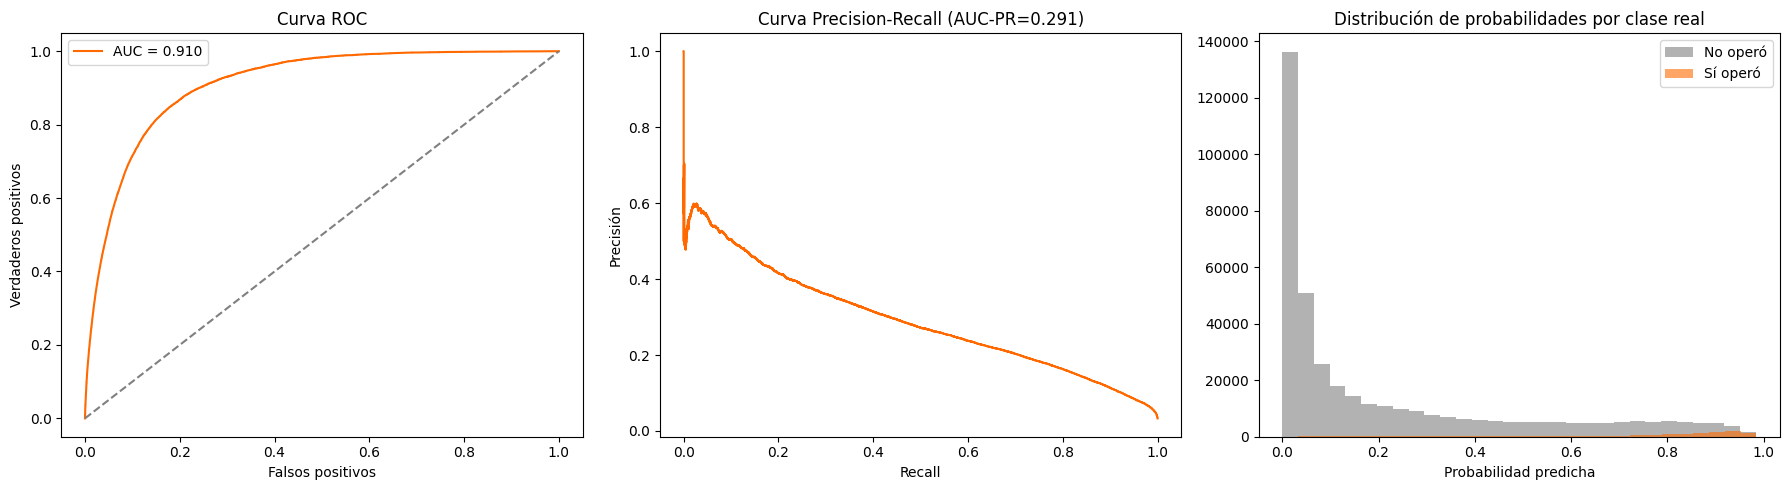


Gráficas guardadas en: C:\Users\lmora\OneDrive\Desktop\Mesa de clientes\models\validacion_abril_mayo_2026.png


In [7]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import os
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report, average_precision_score
)
import matplotlib.pyplot as plt

BASE      = r"C:\Users\lmora\OneDrive\Desktop\Mesa de clientes"
PROCESSED = os.path.join(BASE, 'data', 'processed') + os.sep

features = ['dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'monto_prom_90d',
            'CIIU_BUC', 'Segmento', 'Subsegmento',
            'dia_semana', 'dia_mes', 'mes',
            'TRM_USD', 'variacion_trm_7d']
cat_features = ['CIIU_BUC', 'Segmento', 'Subsegmento']

PARAMS_LGB = {
    'objective': 'binary', 'is_unbalance': True, 'learning_rate': 0.05,
    'max_bin': 63, 'num_leaves': 31, 'min_data_in_leaf': 50,
    'force_col_wise': True, 'verbose': -1, 'seed': 42,
}

# ── 1. Cargar panel completo ─────────────────────────────────────────────
print("Cargando panel diario...")
panel = pd.read_parquet(PROCESSED + 'panel_diario_completo.parquet')
panel['fecha_corte'] = pd.to_datetime(panel['fecha_corte'])
for col in cat_features:
    panel[col] = panel[col].astype('category')

# ── 2. Split temporal: train hasta marzo, validación abril-mayo ─────────
FECHA_CORTE_TRAIN = pd.Timestamp('2026-03-31')   # entrena con todo <= esta fecha
FECHA_INICIO_VAL  = pd.Timestamp('2026-04-01')
FECHA_FIN_VAL     = pd.Timestamp('2026-05-31')   # ajusta si tu mayo no llega completo

train = panel[panel['fecha_corte'] <= FECHA_CORTE_TRAIN].copy()
val   = panel[(panel['fecha_corte'] >= FECHA_INICIO_VAL) &
              (panel['fecha_corte'] <= FECHA_FIN_VAL)].copy()

print(f"Train: {train.shape[0]:,} filas | hasta {train['fecha_corte'].max().date()}")
print(f"Val:   {val.shape[0]:,} filas | de {val['fecha_corte'].min().date()} a {val['fecha_corte'].max().date()}")
print(f"Tasa positiva train: {train['label'].mean():.4f}")
print(f"Tasa positiva val:   {val['label'].mean():.4f}")

# ── 3. Entrenar modelo de validación (solo con datos hasta marzo) ───────
print("\nEntrenando modelo de validación (train hasta marzo 2026)...")
train_set = lgb.Dataset(
    train[features], label=train['label'],
    categorical_feature=cat_features, free_raw_data=False
)
modelo_val = lgb.train(PARAMS_LGB, train_set, num_boost_round=300)

# ── 4. Predecir sobre abril-mayo (datos reales, label conocido) ─────────
val['prob_pred'] = modelo_val.predict(val[features])

# ── 5. Métricas ───────────────────────────────────────────────────────────
y_true = val['label']
y_prob = val['prob_pred']
y_pred = (y_prob >= 0.5).astype(int)   # umbral default; ajusta si usas otro

auc      = roc_auc_score(y_true, y_prob)
pr_auc   = average_precision_score(y_true, y_prob)
cm       = confusion_matrix(y_true, y_pred)
reporte  = classification_report(y_true, y_pred, digits=3)

print(f"\n{'='*50}")
print(f"MÉTRICAS — Validación abril-mayo 2026")
print(f"{'='*50}")
print(f"AUC-ROC:        {auc:.4f}")
print(f"AUC-PR:         {pr_auc:.4f}")
print(f"\nMatriz de confusión:")
print(f"                Pred 0    Pred 1")
print(f"Real 0        {cm[0,0]:>8}  {cm[0,1]:>8}")
print(f"Real 1        {cm[1,0]:>8}  {cm[1,1]:>8}")
print(f"\nReporte de clasificación:")
print(reporte)

# Falsos negativos (clientes que SÍ operaron pero el modelo no detectó)
fn_mask = (y_true == 1) & (y_pred == 0)
print(f"\nFalsos negativos: {fn_mask.sum()} de {y_true.sum()} positivos reales "
      f"({fn_mask.sum() / y_true.sum() * 100:.1f}%)")

# ── 6. Gráficas ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Curva ROC
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0].plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='#FF6900')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_xlabel('Falsos positivos')
axes[0].set_ylabel('Verdaderos positivos')
axes[0].set_title('Curva ROC')
axes[0].legend()

# Curva Precision-Recall
prec, rec, _ = precision_recall_curve(y_true, y_prob)
axes[1].plot(rec, prec, color='#FF6900')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precisión')
axes[1].set_title(f'Curva Precision-Recall (AUC-PR={pr_auc:.3f})')

# Distribución de probabilidades por clase real
axes[2].hist(y_prob[y_true == 0], bins=30, alpha=0.6, label='No operó', color='gray')
axes[2].hist(y_prob[y_true == 1], bins=30, alpha=0.6, label='Sí operó', color='#FF6900')
axes[2].set_xlabel('Probabilidad predicha')
axes[2].set_title('Distribución de probabilidades por clase real')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'models', 'validacion_abril_mayo_2026.png'), dpi=150)
plt.show()

print(f"\nGráficas guardadas en: {os.path.join(BASE, 'models', 'validacion_abril_mayo_2026.png')}")

In [9]:
# ── Precision@K (precision dentro del cupo diario, igual que en producción) ──
import pandas as pd
import numpy as np

CUPO_DIARIO = 800

# val ya tiene 'prob_pred' y 'label' del bloque anterior
# Necesitamos 'Segmento' y 'fecha_corte', que ya están en el dataframe val

resultados_cupo = []

for fecha in sorted(val['fecha_corte'].unique()):
    grupo = val[val['fecha_corte'] == fecha].copy()

    # Misma lógica de reparto de cupo por segmento que usas en producción
    demanda = grupo.groupby('Segmento', observed=True)['prob_pred'].sum()
    props   = demanda / demanda.sum()
    cupos   = (props * CUPO_DIARIO).round().astype(int).clip(lower=1)

    seleccionados = []
    for seg, cupo in cupos.items():
        sub = grupo[grupo['Segmento'] == seg].sort_values('prob_pred', ascending=False)
        seleccionados.append(sub.head(cupo))

    seleccionados = pd.concat(seleccionados, ignore_index=True)

    n_seleccionados = len(seleccionados)
    n_aciertos      = seleccionados['label'].sum()   # de los priorizados, cuántos sí operaron
    precision_dia   = n_aciertos / n_seleccionados if n_seleccionados > 0 else np.nan

    # Para contexto: cuántos positivos reales había ese día en total
    n_positivos_reales = grupo['label'].sum()
    recall_dia = n_aciertos / n_positivos_reales if n_positivos_reales > 0 else np.nan

    resultados_cupo.append({
        'fecha_corte': fecha,
        'n_priorizados': n_seleccionados,
        'aciertos': n_aciertos,
        'precision_cupo': precision_dia,
        'positivos_reales_dia': n_positivos_reales,
        'recall_cupo': recall_dia,
    })

resultados_cupo = pd.DataFrame(resultados_cupo)

print("Resultados diarios (basados en cupo, como en producción):")
print(resultados_cupo.to_string(index=False))

print(f"\n{'='*55}")
print(f"RESUMEN — Precision@Cupo (validación abril-mayo 2026)")
print(f"{'='*55}")
print(f"Precision promedio (por día):     {resultados_cupo['precision_cupo'].mean():.3f}")
print(f"Recall promedio (por día):        {resultados_cupo['recall_cupo'].mean():.3f}")
print(f"Total priorizados:                {resultados_cupo['n_priorizados'].sum():,}")
print(f"Total aciertos:                   {resultados_cupo['aciertos'].sum():,}")
print(f"Precision global (agregada):      {resultados_cupo['aciertos'].sum() / resultados_cupo['n_priorizados'].sum():.3f}")

Resultados diarios (basados en cupo, como en producción):
fecha_corte  n_priorizados  aciertos  precision_cupo  positivos_reales_dia  recall_cupo
 2026-04-01            799       179        0.224030                   302     0.592715
 2026-04-06            798       141        0.176692                   269     0.524164
 2026-04-07            799       246        0.307885                   469     0.524520
 2026-04-08            800       206        0.257500                   377     0.546419
 2026-04-09            799       243        0.304130                   441     0.551020
 2026-04-10            801       255        0.318352                   474     0.537975
 2026-04-13            798       253        0.317043                   510     0.496078
 2026-04-14            800       159        0.198750                   314     0.506369
 2026-04-15            800       156        0.195000                   317     0.492114
 2026-04-16            800       171        0.213750          

In [10]:
tasa_base = val['label'].mean()  # tasa positiva real en el período (≈0.0332)
precision_modelo = 0.240
lift = precision_modelo / tasa_base

print(f"Tasa base (azar):        {tasa_base:.4f}")
print(f"Precision del modelo:    {precision_modelo:.4f}")
print(f"Lift vs. azar:           {lift:.1f}x")

Tasa base (azar):        0.0332
Precision del modelo:    0.2400
Lift vs. azar:           7.2x
